# Initialization

In [122]:
# ---- Patch 0: safer GPU config (run once, near the top) ----
import tensorflow as tf
tf.config.set_soft_device_placement(True)  # let TF fallback to CPU if needed

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) found and memory growth enabled: {gpus}")
    except Exception as e:
        print("Could not enable memory growth:", e)
else:
    print("No GPU detected; running on CPU.")


GPU(s) found and memory growth enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [123]:
import glob
import numpy as np

npy_files = glob.glob('cached_np/*.npy')
data_arrays = {file.split('/')[-1].replace('.npy', ''): np.load(file) for file in npy_files}

print(f"Loaded {len(data_arrays)} variables from .npy files.")


Loaded 7 variables from .npy files.


# Preprocessing

In [124]:
vars_to_check = [
    'X_all',
    'Y_all',
    'wrench_all',
    'Z_all',
    'angles_all',
    'wrench_out_all',
    'currents_all'
]

for name in vars_to_check:
    if name in data_arrays:
        arr = np.array(data_arrays[name])
        print(f"{name}: shape={arr.shape}, dtype={arr.dtype}, "
              f"min={np.nanmin(arr):.6f}, max={np.nanmax(arr):.6f}, "
              f"NaNs={np.isnan(arr).sum()}")
    else:
        print(f"{name}: NOT FOUND in data_arrays")


X_all: shape=(1, 1411344), dtype=float64, min=-0.150000, max=0.150000, NaNs=0
Y_all: shape=(1, 1411344), dtype=float64, min=-0.150000, max=0.150000, NaNs=0
wrench_all: shape=(6, 1411344), dtype=float64, min=-71.323061, max=67.910946, NaNs=0
Z_all: shape=(1, 1411344), dtype=float64, min=0.005000, max=0.005000, NaNs=0
angles_all: shape=(3, 1411344), dtype=float64, min=-3.141593, max=3.141593, NaNs=0
wrench_out_all: shape=(6, 1411344), dtype=float64, min=-43712933.130251, max=36944979.677285, NaNs=0
currents_all: shape=(16, 1411344), dtype=float64, min=-5885.689556, max=16889.743946, NaNs=0


In [125]:
# Build ARR as [N,16] from whatever you loaded. Then re-run the previous analysis cell.

import numpy as np

def find_currents_matrix(dct):
    # 2D with 16 cols
    for v in dct.values():
        a = np.array(v)
        if a.ndim == 2 and a.shape[1] == 16:
            return a
    # 2D with 16 rows -> transpose
    for v in dct.values():
        a = np.array(v)
        if a.ndim == 2 and a.shape[0] == 16:
            return a.T
    # 1D or weird -> reshape by 16
    for v in dct.values():
        a = np.array(v).ravel()
        if a.size % 16 == 0 and a.size >= 16:
            return a.reshape(-1, 16)
    raise ValueError("No 16-current structure found in data_arrays.")

ARR = find_currents_matrix(data_arrays)
print("ARR shape:", ARR.shape)

ARR shape: (1411344, 16)


In [126]:
# Ensure shape is [N_samples, N_channels]
W = np.array(data_arrays['wrench_out_all'], dtype=float)
if W.shape[0] < W.shape[1]:
    W = W.T  # transpose to get samples as rows

print("Fixed wrench_out_all shape:", W.shape)  # should be (1895400, 6)

Fixed wrench_out_all shape: (1411344, 6)


In [127]:
import numpy as np

# Preprocess into sample-aligned arrays

def to_samples_first(arr):
    arr = np.array(arr, dtype=float)
    if arr.shape[0] < arr.shape[1]:
        arr = arr.T
    return arr

# Flatten small coordinate arrays
def flatten_coord(arr):
    return np.array(arr, dtype=float).ravel()

X_all = flatten_coord(data_arrays['X_all'])
Y_all = flatten_coord(data_arrays['Y_all'])
Z_all = flatten_coord(data_arrays['Z_all'])
angles_all = np.array(data_arrays['angles_all'], dtype=float)
if angles_all.shape[0] < angles_all.shape[1]:
    angles_all = angles_all.T  # now shape [N, 3]

wrench_all = to_samples_first(data_arrays['wrench_all'])          # [N, 6]
wrench_out_all = to_samples_first(data_arrays['wrench_out_all'])  # [N, 6]
currents_all = to_samples_first(data_arrays['currents_all'])      # [N, 16]

# Sanity check: all sample counts
N_samples = max(len(X_all), wrench_all.shape[0], currents_all.shape[0])
print("Sample counts:")
print(f"X_all:           {X_all.shape}")
print(f"Y_all:           {Y_all.shape}")
print(f"Z_all:           {Z_all.shape}")
print(f"angles_all:      {angles_all.shape}")
print(f"wrench_all:      {wrench_all.shape}")
print(f"wrench_out_all:  {wrench_out_all.shape}")
print(f"currents_all:    {currents_all.shape}")

# Verify alignment
if not (len(X_all) == len(Y_all) == len(Z_all) == angles_all.shape[0] == wrench_all.shape[0] == wrench_out_all.shape[0] == currents_all.shape[0]):
    print("WARNING: Arrays differ in length, need resampling or trimming.")
else:
    print("All arrays aligned to", N_samples, "samples.")


Sample counts:
X_all:           (1411344,)
Y_all:           (1411344,)
Z_all:           (1411344,)
angles_all:      (1411344, 3)
wrench_all:      (1411344, 6)
wrench_out_all:  (1411344, 6)
currents_all:    (1411344, 16)
All arrays aligned to 1411344 samples.


## Creating the Dataframe

In [128]:
import numpy as np
import pandas as pd


# Build dataframe
df = pd.DataFrame()

# Y, Z from data
df['X'] = X_all
df['Y'] = Y_all
df['Z'] = Z_all

# Angles
for i in range(angles_all.shape[1]):
    df[f'angle_{i+1}'] = angles_all[:, i]

# Wrench (input)
for i, name in enumerate(["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]):
    df[f'wrench_{name}'] = wrench_all[:, i]

# Wrench out
for i, name in enumerate(["Fx", "Fy", "Fz", "Tx", "Ty", "Tz"]):
    df[f'wrench_out_{name}'] = wrench_out_all[:, i]

# Currents
for i in range(currents_all.shape[1]):
    df[f'current_{i+1}'] = currents_all[:, i]

print("Final dataset shape:", df.shape)
print(df.head(10))


Final dataset shape: (1411344, 34)
          X     Y      Z   angle_1   angle_2   angle_3  wrench_Fx  wrench_Fy  \
0 -0.150000 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
1 -0.140625 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
2 -0.131250 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
3 -0.121875 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
4 -0.112500 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
5 -0.103125 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
6 -0.093750 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
7 -0.084375 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
8 -0.075000 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   
9 -0.065625 -0.15  0.005 -0.087266 -0.087266 -3.141593        1.0        0.0   

   wrench_Fz  wrench_Tx  ...  current_7  current_8  current_9  current_10  \
0      

# Data Analysis

## Wrench Investigation

Wrench summary:
  channel        min        p01       p25    median      mean        p75  \
0      Fx -71.762163 -35.896928 -7.649506 -0.000000 -2.004577   1.960230   
1      Fy -71.762163 -30.437419 -3.339252  0.022254  2.602734   8.828112   
2      Fz -71.762163 -68.943046 -2.149142  0.553492  6.656157  17.823183   
3      Tx -71.762163 -14.189055 -2.521515 -0.000000 -0.551370   1.014062   
4      Ty -66.109715 -13.550148 -0.965381  0.000000  0.083460   1.450946   
5      Tz -71.762163 -10.271214 -0.110946  0.341150  1.190018   2.892426   

         p99        max        std      skew       kurt  
0  28.626263  72.990359  13.312557 -0.141276   2.333586  
1  41.769258  72.990359  14.248236  0.500969   2.029865  
2  68.505280  72.990359  30.118061 -0.020711   0.486861  
3  13.673413  72.990359   4.541524 -0.022875   7.745742  
4  13.975309  72.990359   4.276740  0.062824  11.279306  
5  12.477598  72.990359   3.992579  0.552637  44.553678  


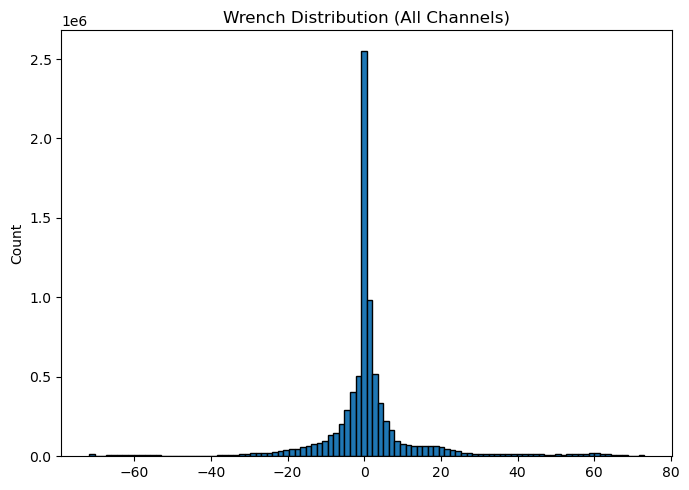

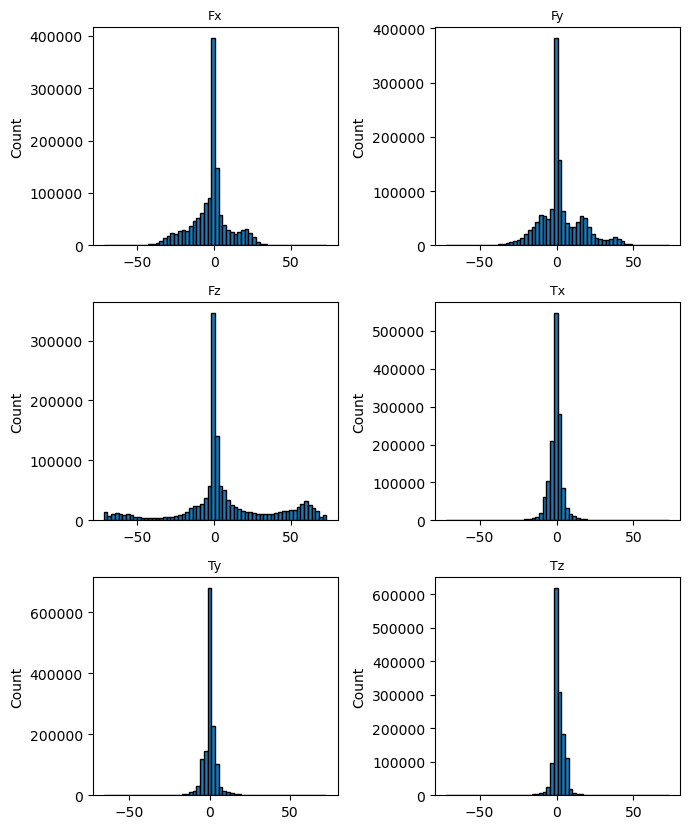

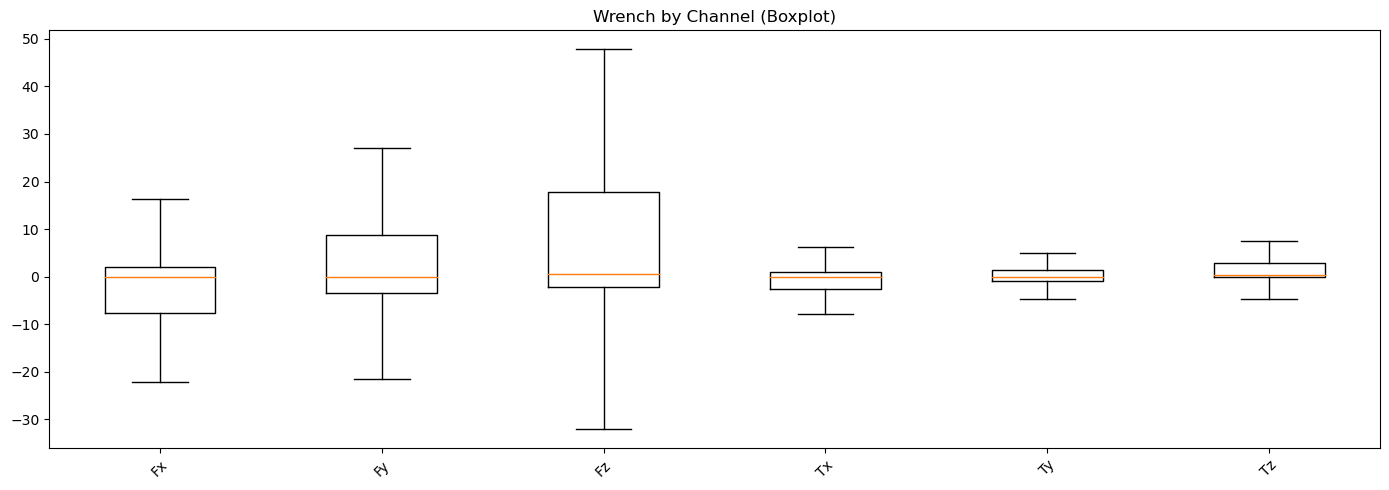

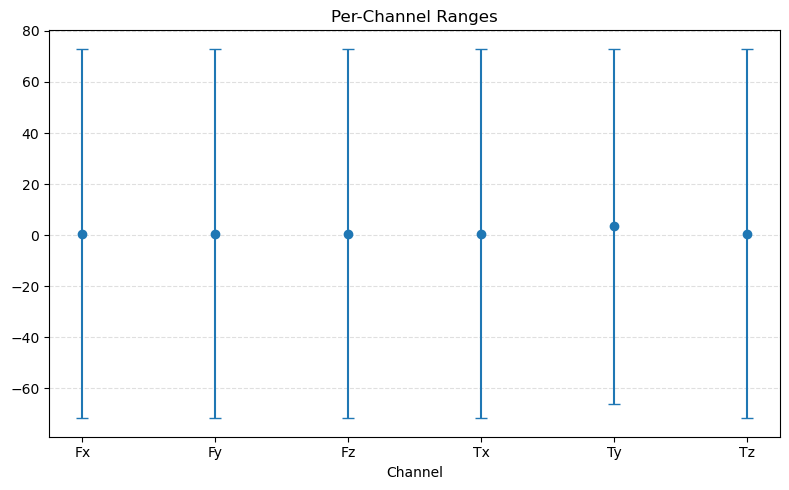

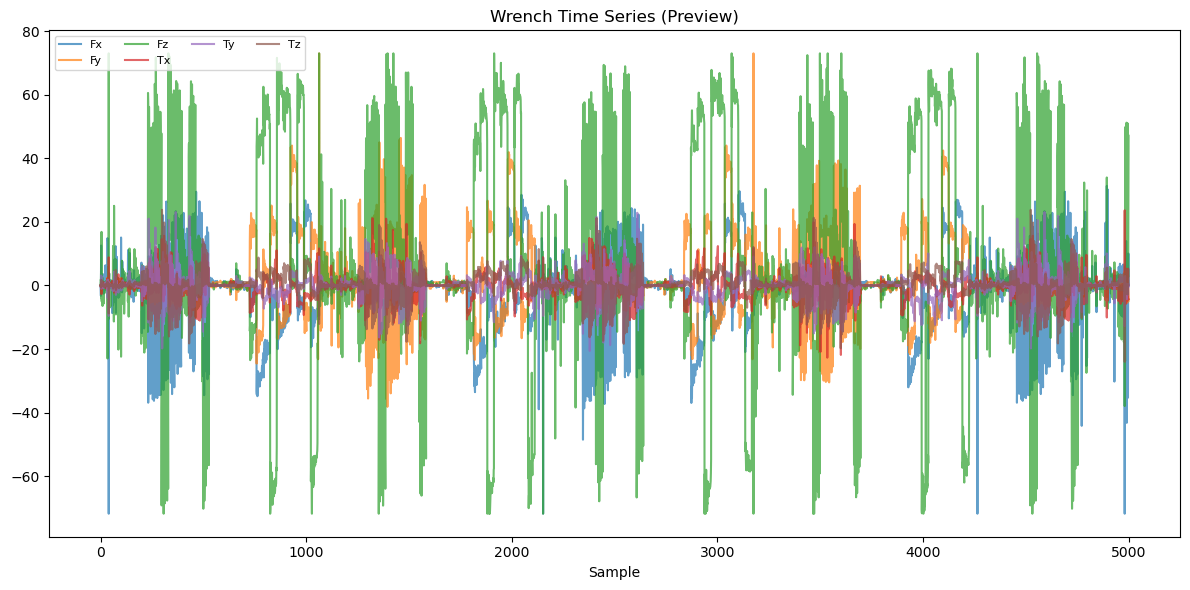

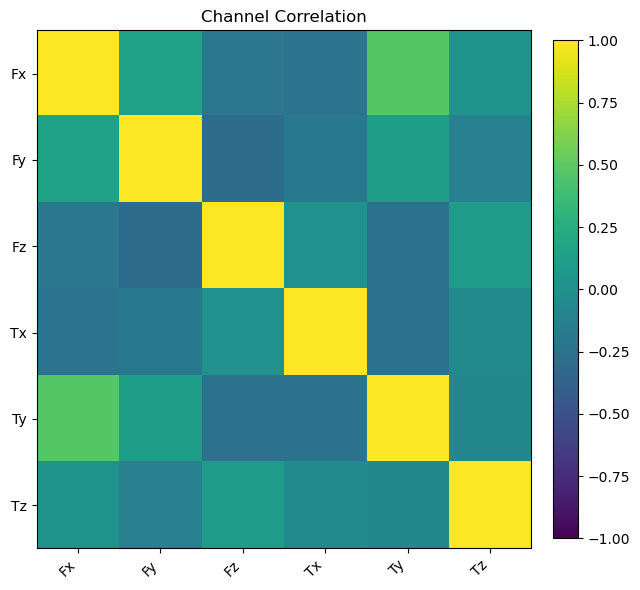

Saved wrench figures -> /home/alireza-linux/MLPM/ML_Project/analysis_plots_wrench


In [8]:
# Run full analysis for wrench_out_all (reuses same plotting style)

FS = None  # set if you know sampling rate
cols = W.shape[1]

# Channel names guess
if cols == 6:
    CH = ["Fx","Fy","Fz","Tx","Ty","Tz"]
elif cols == 12:
    CH = [f"F{i}" for i in range(1,7)] + [f"T{i}" for i in range(1,7)]
else:
    CH = [f"C{i:02d}" for i in range(1, cols+1)]

UNITS = ""          # leave blank if mixed units
SAVE_DIR = "analysis_plots_wrench"
CLIP_QUANTILES = (0.001, 0.999)
SMOOTH_WINDOW = 0

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal, stats

X = np.array(W, dtype=float)
X[~np.isfinite(X)] = np.nan
mask_valid = ~np.all(np.isnan(X), axis=1)
X = X[mask_valid]

if CLIP_QUANTILES:
    lo, hi = np.nanquantile(X, CLIP_QUANTILES[0]), np.nanquantile(X, CLIP_QUANTILES[1])
    X = np.clip(X, lo, hi)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1:
    k = np.ones(SMOOTH_WINDOW)/SMOOTH_WINDOW
    X = np.apply_along_axis(lambda s: np.convolve(np.nan_to_num(s, nan=np.nanmean(s)), k, mode='same'), 0, X)

t = np.arange(X.shape[0]) if not FS else np.arange(X.shape[0])/float(FS)
txlabel = "Sample" if not FS else "Time (s)"

os.makedirs(SAVE_DIR, exist_ok=True)

# Summary
summary = pd.DataFrame({
    "channel": CH,
    "min":   np.nanmin(X, axis=0),
    "p01":   np.nanpercentile(X, 1, axis=0),
    "p25":   np.nanpercentile(X, 25, axis=0),
    "median":np.nanmedian(X, axis=0),
    "mean":  np.nanmean(X, axis=0),
    "p75":   np.nanpercentile(X, 75, axis=0),
    "p99":   np.nanpercentile(X, 99, axis=0),
    "max":   np.nanmax(X, axis=0),
    "std":   np.nanstd(X, axis=0, ddof=1),
    "skew":  [stats.skew(X[:,i], nan_policy='omit', bias=False) for i in range(cols)],
    "kurt":  [stats.kurtosis(X[:,i], nan_policy='omit', bias=False) for i in range(cols)],
})
print("Wrench summary:")
print(summary.round(6))

# Overall distribution
plt.figure(figsize=(7,5))
plt.hist(X.ravel(), bins=100, edgecolor='black')
plt.title("Wrench Distribution (All Channels)")
plt.xlabel(UNITS); plt.ylabel("Count")
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/hist_all.png", dpi=150); plt.show()

# Per-channel hist
r = int(np.ceil(np.sqrt(cols))); c = int(np.ceil(cols/r))
fig, axes = plt.subplots(r, c, figsize=(3.5*c, 2.8*r))
axes = np.array(axes).ravel()
for i in range(cols):
    axes[i].hist(X[:, i], bins=60, edgecolor='black')
    axes[i].set_title(CH[i], fontsize=9)
    axes[i].set_xlabel(UNITS); axes[i].set_ylabel("Count")
for j in range(cols, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/hist_per_channel.png", dpi=180); plt.show()

# Boxplot
plt.figure(figsize=(min(16, 1.0*cols)+8, 5))
plt.boxplot([X[:,i] for i in range(cols)], showfliers=False, labels=CH)
plt.title("Wrench by Channel (Boxplot)")
plt.ylabel(UNITS); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/boxplot.png", dpi=150); plt.show()

# Ranges
mn, mx = np.nanmin(X,0), np.nanmax(X,0)
centers, half_rng = (mn+mx)/2, (mx-mn)/2
idx = np.arange(1, cols+1)
plt.figure(figsize=(max(8, 0.6*cols), 5))
plt.errorbar(idx, centers, yerr=half_rng, fmt='o', capsize=4)
plt.xticks(idx, CH, rotation=0)
plt.title("Per-Channel Ranges")
plt.xlabel("Channel"); plt.ylabel(UNITS)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/ranges.png", dpi=150); plt.show()

# Time preview
N_preview = min(X.shape[0], int(10*FS) if FS else 5000)
plt.figure(figsize=(12,6))
for i in range(cols):
    plt.plot(t[:N_preview], X[:N_preview, i], alpha=0.7, label=CH[i])
plt.title("Wrench Time Series (Preview)")
plt.xlabel(txlabel); plt.ylabel(UNITS)
plt.legend(ncol=min(4, cols), fontsize=8)
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/timeseries_preview.png", dpi=150); plt.show()

# Correlation
corr = np.corrcoef(X.T)
plt.figure(figsize=(6.5,6))
im = plt.imshow(corr, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(cols), CH, rotation=45, ha='right')
plt.yticks(np.arange(cols), CH)
plt.title("Channel Correlation")
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/corr_heatmap.png", dpi=150); plt.show()


print(f"Saved wrench figures -> {os.path.abspath(SAVE_DIR)}")


## Currents Investigation

### Statistical plots of the currents in the dataset

Summary:
   channel   min   p01        p25  median      mean        p75   p99   max  \
0      I01 -10.0 -10.0  -9.999998     0.0 -0.014177   9.999997  10.0  10.0   
1      I02 -10.0 -10.0 -10.000000     0.0 -0.009607  10.000000  10.0  10.0   
2      I03 -10.0 -10.0 -10.000000     0.0 -0.007018  10.000000  10.0  10.0   
3      I04 -10.0 -10.0  -9.999947     0.0 -0.004106   9.999942  10.0  10.0   
4      I05 -10.0 -10.0 -10.000000     0.0 -0.001412  10.000000  10.0  10.0   
5      I06 -10.0 -10.0 -10.000000     0.0  0.006206  10.000000  10.0  10.0   
6      I07 -10.0 -10.0 -10.000000     0.0  0.005911  10.000000  10.0  10.0   
7      I08 -10.0 -10.0  -9.676148     0.0 -0.003654   9.650259  10.0  10.0   
8      I09 -10.0 -10.0  -8.193575     0.0 -0.001812   8.162526  10.0  10.0   
9      I10 -10.0 -10.0  -8.487969     0.0  0.006065   8.543623  10.0  10.0   
10     I11 -10.0 -10.0  -6.750586     0.0  0.005555   6.812999  10.0  10.0   
11     I12 -10.0 -10.0  -5.005669     0.0 -0.003962   4

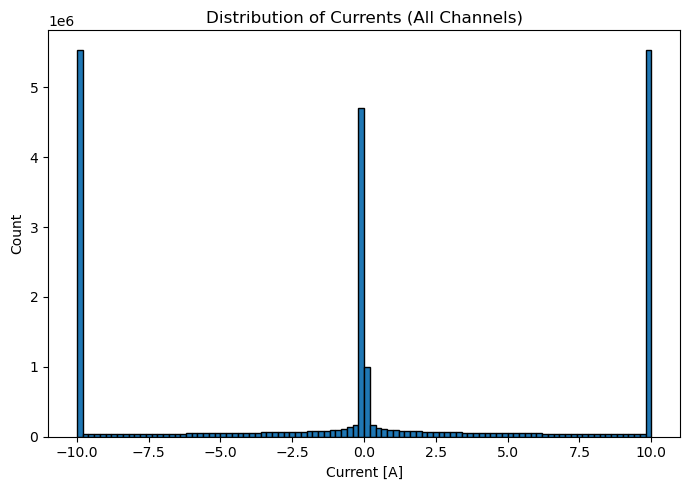

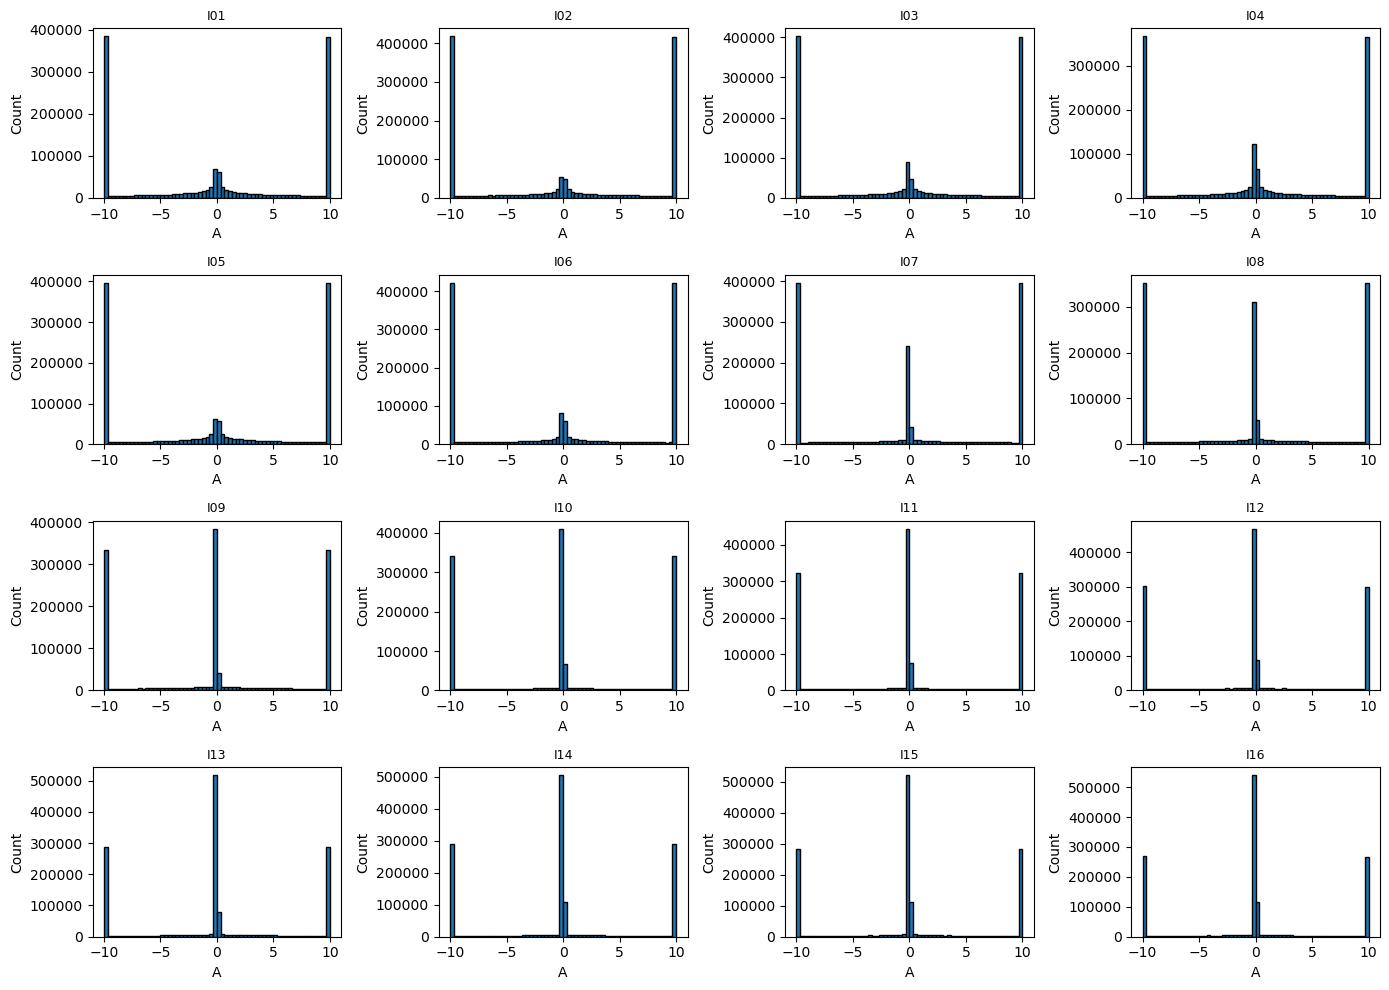

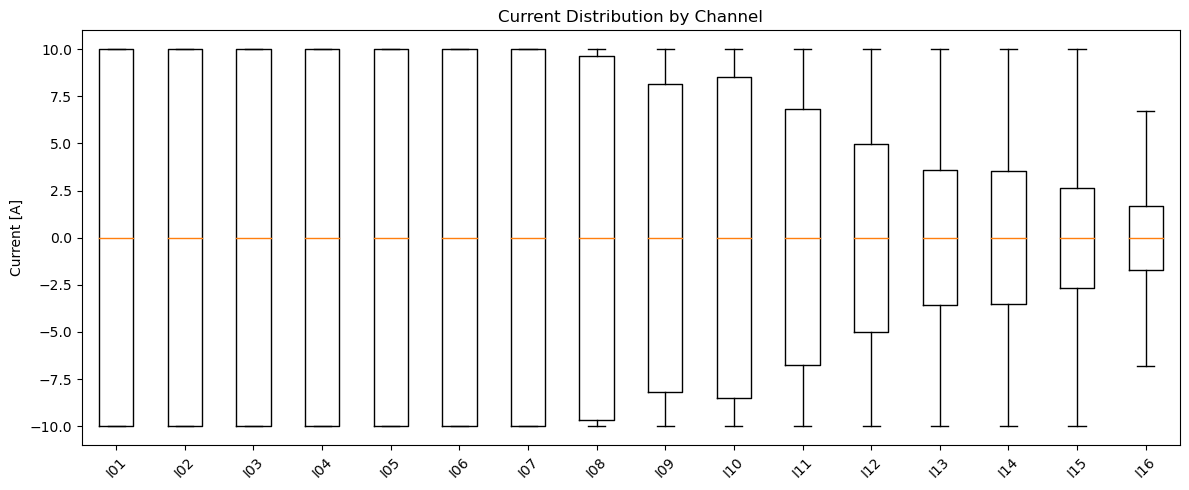

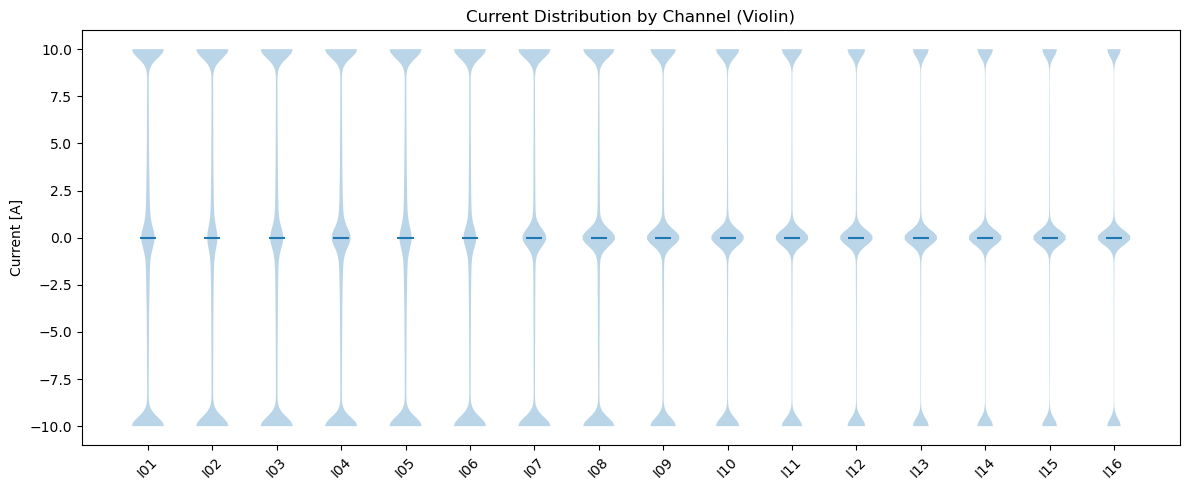

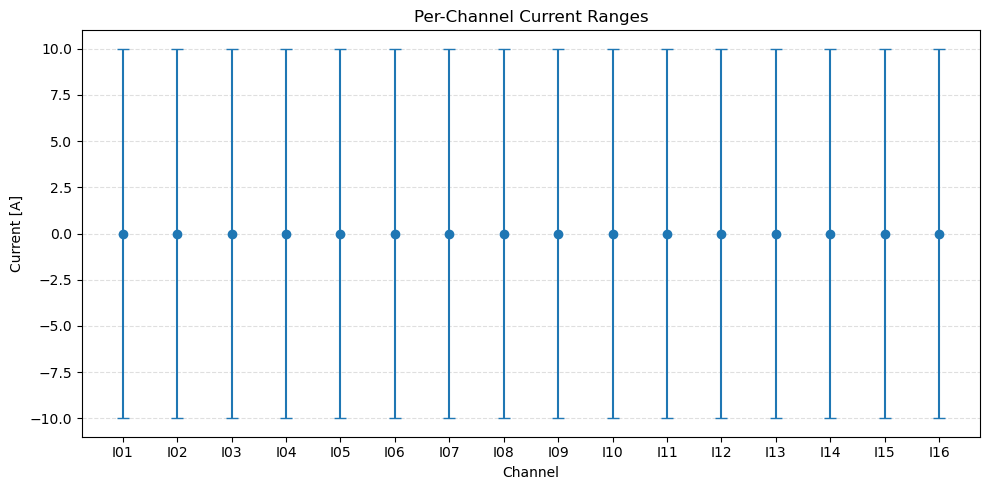

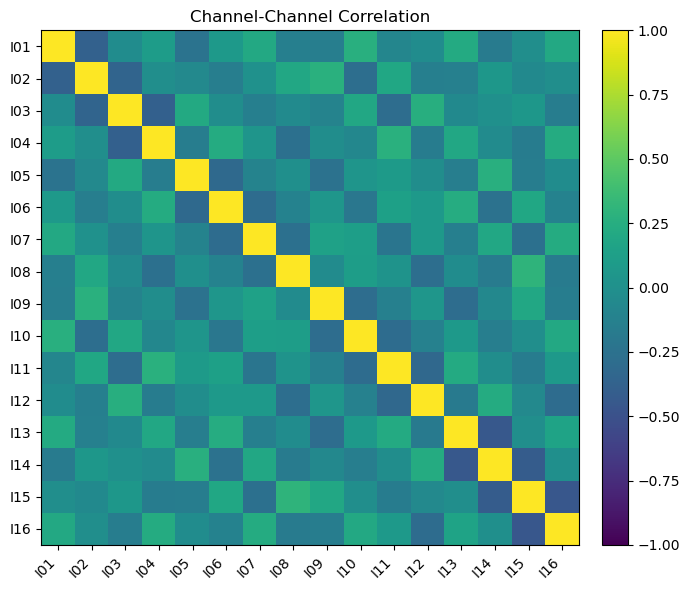

In [9]:
# Use existing ARR = [N,16] to run full analysis

# === CONFIG ===
FS = None          # sampling rate in Hz (None => x-axis in samples)
CHANNEL_NAMES = [f"I{i:02d}" for i in range(1,17)]
UNITS = "A"
CLIP_QUANTILES = (0.001, 0.999)  # None to disable
SMOOTH_WINDOW = 0                # 0/None to disable
SAVE_DIR = "analysis_plots"
# ==============

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal, stats

assert ARR.ndim == 2 and ARR.shape[1] == 16, "ARR must be [N,16]"

# --- Preprocess ---
X = np.array(ARR, dtype=float)
X[~np.isfinite(X)] = np.nan
mask_valid = ~np.all(np.isnan(X), axis=1)
X = X[mask_valid]

if CLIP_QUANTILES:
    lo, hi = np.nanquantile(X, CLIP_QUANTILES[0]), np.nanquantile(X, CLIP_QUANTILES[1])
    X = np.clip(X, lo, hi)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1:
    k = np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW
    X = np.apply_along_axis(lambda s: np.convolve(np.nan_to_num(s, nan=np.nanmean(s)), k, mode='same'), 0, X)

t = np.arange(X.shape[0]) if not FS else np.arange(X.shape[0]) / float(FS)
txlabel = "Sample" if not FS else "Time (s)"

os.makedirs(SAVE_DIR, exist_ok=True)

# --- Summary stats ---
summary = pd.DataFrame({
    "channel": CHANNEL_NAMES,
    "min":   np.nanmin(X, axis=0),
    "p01":   np.nanpercentile(X, 1, axis=0),
    "p25":   np.nanpercentile(X, 25, axis=0),
    "median":np.nanmedian(X, axis=0),
    "mean":  np.nanmean(X, axis=0),
    "p75":   np.nanpercentile(X, 75, axis=0),
    "p99":   np.nanpercentile(X, 99, axis=0),
    "max":   np.nanmax(X, axis=0),
    "std":   np.nanstd(X, axis=0, ddof=1),
    "skew":  [stats.skew(X[:,i], nan_policy='omit', bias=False) for i in range(16)],
    "kurt":  [stats.kurtosis(X[:,i], nan_policy='omit', bias=False) for i in range(16)],
})
print("Summary:")
print(summary.round(6))

# --- Overall distribution ---
plt.figure(figsize=(7,5))
plt.hist(X.ravel(), bins=100, edgecolor='black')
plt.title("Distribution of Currents (All Channels)")
plt.xlabel(f"Current [{UNITS}]"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/hist_all.png", dpi=150); plt.show()

# --- Per-channel hist (4x4) ---
fig, axes = plt.subplots(4,4, figsize=(14,10))
axes = axes.ravel()
for i in range(16):
    axes[i].hist(X[:, i], bins=60, edgecolor='black')
    axes[i].set_title(CHANNEL_NAMES[i], fontsize=9)
    axes[i].set_xlabel(UNITS); axes[i].set_ylabel("Count")
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/hist_per_channel.png", dpi=180); plt.show()

# --- Boxplot ---
plt.figure(figsize=(12,5))
plt.boxplot([X[:,i] for i in range(16)], showfliers=False, labels=CHANNEL_NAMES)
plt.title("Current Distribution by Channel")
plt.ylabel(f"Current [{UNITS}]"); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/boxplot_channels.png", dpi=150); plt.show()

# --- Violin ---
plt.figure(figsize=(12,5))
plt.violinplot([X[:,i] for i in range(16)], showmeans=True, showextrema=False)
plt.title("Current Distribution by Channel (Violin)")
plt.ylabel(f"Current [{UNITS}]")
plt.xticks(ticks=np.arange(1,17), labels=CHANNEL_NAMES, rotation=45)
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/violin_channels.png", dpi=150); plt.show()

# --- Range per channel ---
col_min, col_max = np.nanmin(X,0), np.nanmax(X,0)
centers, half_rng = (col_min+col_max)/2, (col_max-col_min)/2
x = np.arange(1,17)
plt.figure(figsize=(10,5))
plt.errorbar(x, centers, yerr=half_rng, fmt='o', capsize=4)
plt.xticks(x, CHANNEL_NAMES); plt.title("Per-Channel Current Ranges")
plt.xlabel("Channel"); plt.ylabel(f"Current [{UNITS}]")
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/ranges_channels.png", dpi=150); plt.show()

# --- Correlation heatmap ---
corr = np.corrcoef(X.T)
plt.figure(figsize=(7,6))
im = plt.imshow(corr, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(16), CHANNEL_NAMES, rotation=45, ha='right')
plt.yticks(np.arange(16), CHANNEL_NAMES)
plt.title("Channel-Channel Correlation")
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/corr_heatmap.png", dpi=150); plt.show()



### Currents values over the plane at fixed orientation and input

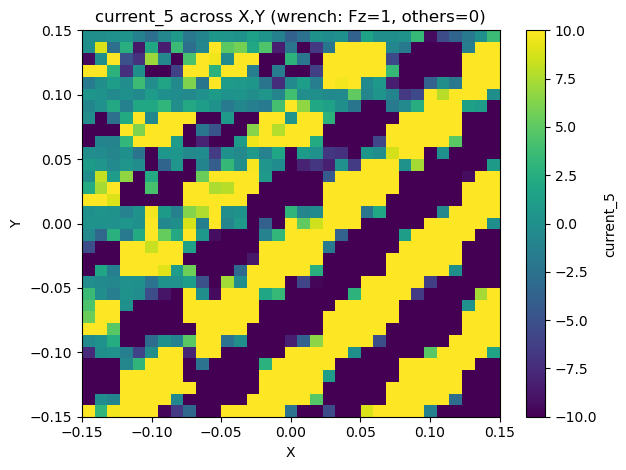

In [18]:
# filter to the fixed input wrench: Fx=Fy=Tx=Ty=Tz=0, Fz=1
w_cols = ['wrench_Fx','wrench_Fy','wrench_Fz','wrench_Tx','wrench_Ty','wrench_Tz']
df_ = df[(df['wrench_Fx']==0)&(df['wrench_Fy']==0)&(df['wrench_Fz']==0)&
         (df['wrench_Tx']==0)&(df['wrench_Ty']==1)&(df['wrench_Tz']==0)].copy()

# drop/ignore wrench_out*
df_ = df_.drop(columns=[c for c in df_.columns if c.startswith('wrench_out_')], errors='ignore')

# keep other things fixed: pick one unique value for every non-(X,Y,current_*,wrench_*) column
fixed_candidates = [
    c for c in df_.columns
    if c not in ['X','Y','current_1'] and not c.startswith('current_') and not c.startswith('wrench_')
]
for c in fixed_candidates:
    vals = df_[c].dropna().unique()
    if len(vals) > 0:
        df_ = df_[df_[c] == vals[0]]

# make a grid of current_1 over X,Y
grid = df_.pivot_table(index='Y', columns='X', values='current_16', aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)

# plot
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label='current_5')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('current_5 across X,Y (wrench: Fz=1, others=0)')
plt.tight_layout()


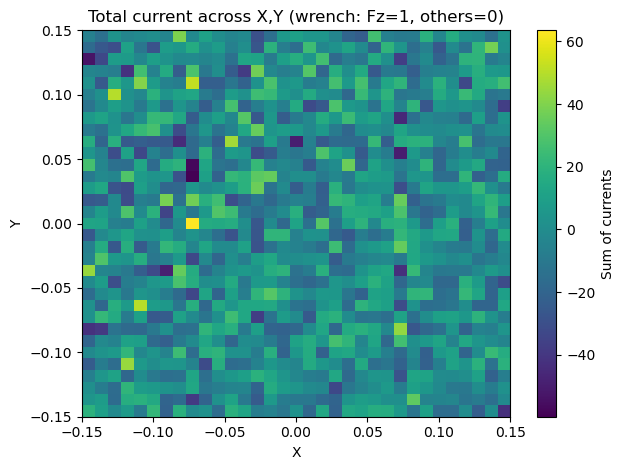

In [11]:
# sum all currents
current_cols = [c for c in df_.columns if c.startswith('current_')]
df_['current_sum'] = df_[current_cols].sum(axis=1)

# make grid over X,Y for the sum
grid = df_.pivot_table(index='Y', columns='X', values='current_sum', aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)

# plot
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label='Sum of currents')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('Total current across X,Y (wrench: Fz=1, others=0)')
plt.tight_layout()

### Currents dependancy on angles analysis

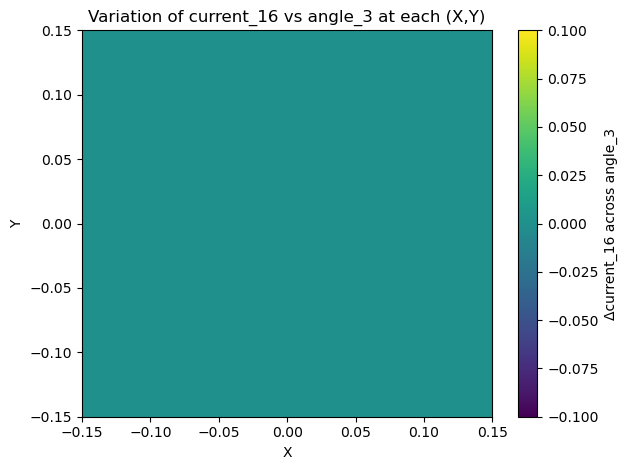

In [21]:
# keep angle_3 free; fix everything else (angles 1&2 fixed)
fixed_cols = [
    c for c in df_.columns
    if c not in ['X','Y','angle_3'] and not c.startswith('current_') and not c.startswith('wrench_')
]
for c in fixed_cols:
    vals = df_[c].dropna().unique()
    if len(vals): df_ = df_[df_[c] == vals[0]]

# ---- choose what to measure ----
# (A) total current variation across angle_3
current_cols = [c for c in df_.columns if c.startswith('current_')]
df_['current_sum'] = df_[current_cols].sum(axis=1)
target = 'current_sum'

# # (B) single coil instead (uncomment to use)
target = 'current_16'

# range (max - min) over angle_3 at each (X,Y)
delta_xy = (df_.groupby(['X','Y'])[target]
              .agg(lambda s: s.max() - s.min())
              .reset_index(name='delta'))

# heatmap
grid = delta_xy.pivot(index='Y', columns='X', values='delta').sort_index().sort_index(axis=1)

import matplotlib.pyplot as plt
plt.figure()
plt.imshow(
    grid.values, origin='lower', aspect='auto',
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
)
plt.colorbar(label=f'Δ{target} across angle_3')
plt.xlabel('X'); plt.ylabel('Y')
plt.title(f'Variation of {target} vs angle_3 at each (X,Y)')
plt.tight_layout()


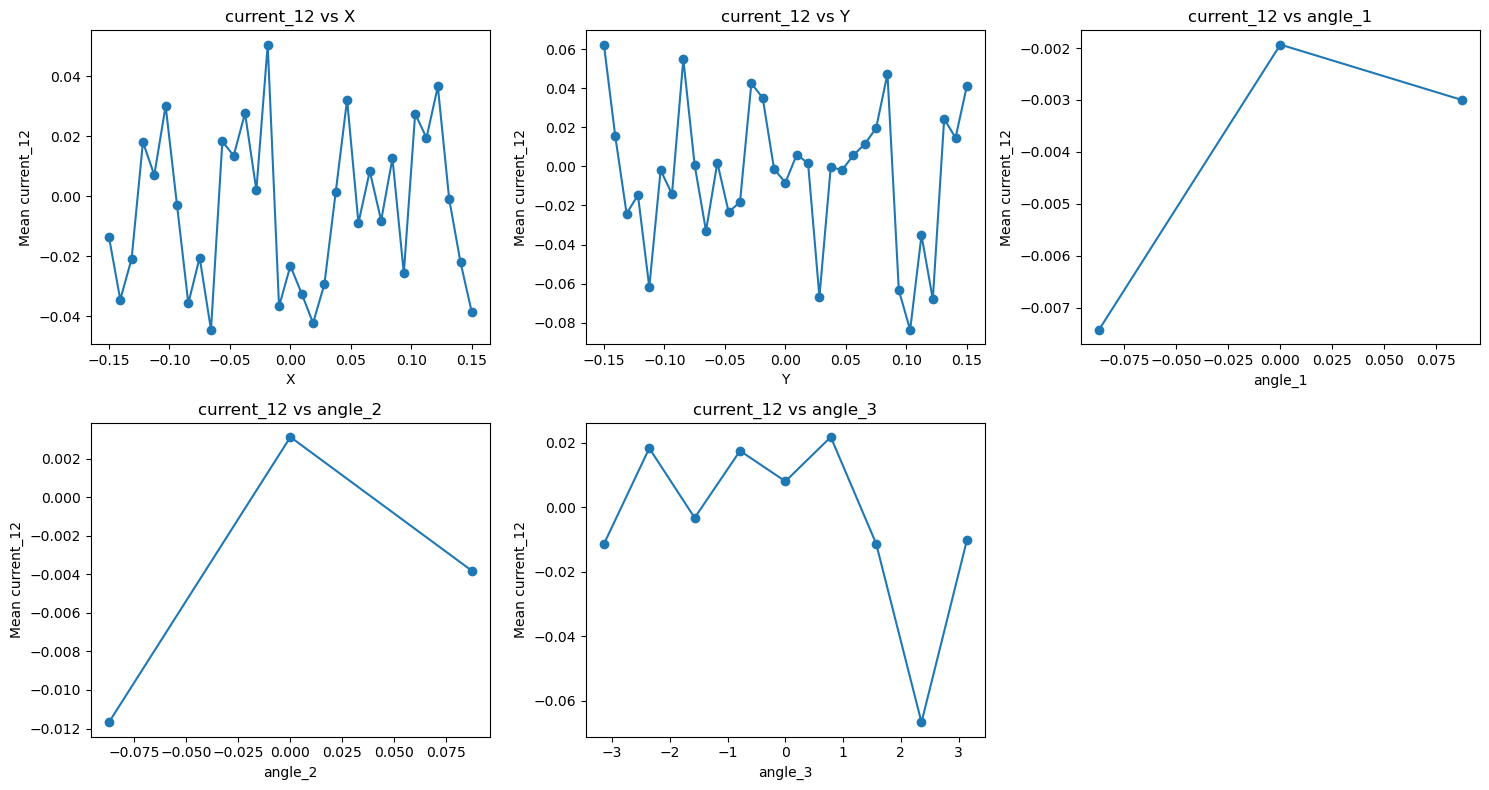

In [13]:
import matplotlib.pyplot as plt

target = 'current_12'  # change to current_5 or others if you want

vars_to_check = ['X', 'Y', 'angle_1', 'angle_2', 'angle_3']

plt.figure(figsize=(15, 8))

for i, var in enumerate(vars_to_check, 1):
    mean_vals = df.groupby(var)[target].mean().reset_index()
    plt.subplot(2, 3, i)
    plt.plot(mean_vals[var], mean_vals[target], marker='o')
    plt.xlabel(var)
    plt.ylabel(f"Mean {target}")
    plt.title(f"{target} vs {var}")

plt.tight_layout()
plt.show()


### Current values over dataset samples

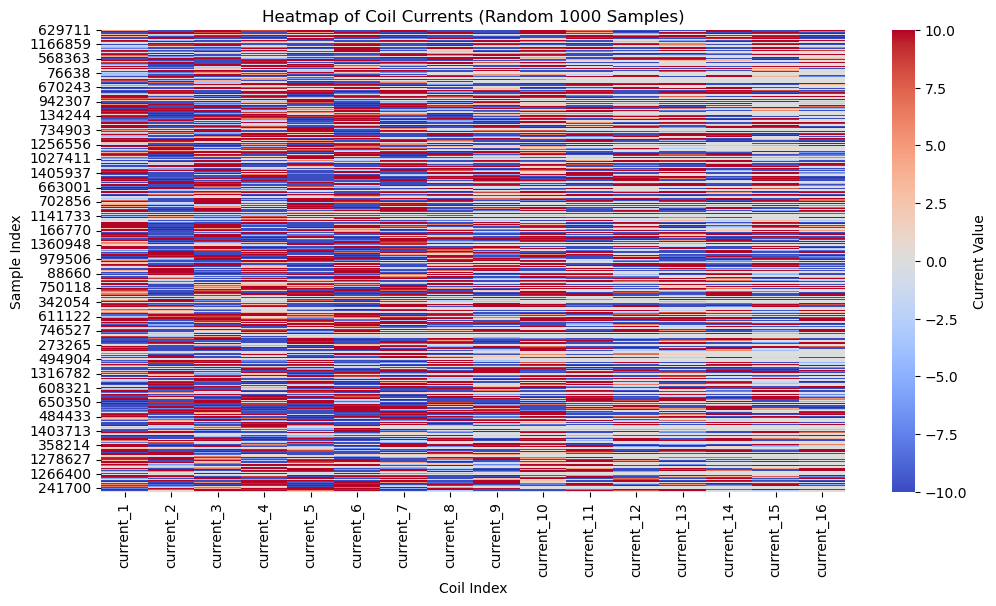

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pick 1000 random samples
curr_cols = [c for c in df.columns if c.startswith('current_')]
rand_idx = np.random.choice(df.index, size=1000, replace=False)
currents_subset = df.loc[rand_idx, curr_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(currents_subset, cmap='coolwarm', center=0, cbar_kws={'label': 'Current Value'})
plt.xlabel('Coil Index')
plt.ylabel('Sample Index')
plt.title('Heatmap of Coil Currents (Random 1000 Samples)')
plt.show()


### Frequency Analysis of currents over X-Y Plane

Visualize for one coil as an example

Dominant spatial frequency vector: (9.6970, -9.6970)
Dominant wavelength: 0.0729 units
Orientation of bands: -45.00 degrees


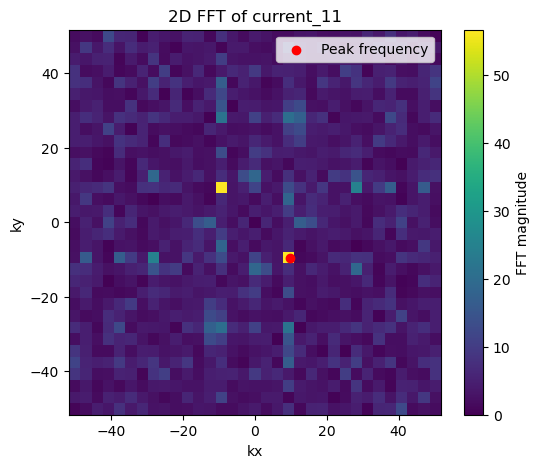

In [22]:
import numpy as np
import matplotlib.pyplot as plt

target = 'current_11'  # change if you want another coil

# Pivot into a 2D grid
grid = df.pivot_table(index='Y', columns='X', values=target, aggfunc='mean')
grid = grid.sort_index().sort_index(axis=1)  # sort axes

# Coordinates
X_coords = grid.columns.to_numpy()
Y_coords = grid.index.to_numpy()

# FFT
F = np.fft.fftshift(np.fft.fft2(grid.fillna(0).to_numpy()))
F_mag = np.abs(F)

# Find dominant frequency (ignore DC component)
center = tuple(np.array(F_mag.shape) // 2)
F_mag[center] = 0
peak_idx = np.unravel_index(np.argmax(F_mag), F_mag.shape)

# Frequency steps
dx = X_coords[1] - X_coords[0]
dy = Y_coords[1] - Y_coords[0]
kx = np.fft.fftshift(np.fft.fftfreq(len(X_coords), d=dx))
ky = np.fft.fftshift(np.fft.fftfreq(len(Y_coords), d=dy))

peak_kx = kx[peak_idx[1]]
peak_ky = ky[peak_idx[0]]

# Wavelength & orientation
wavelength = 1 / np.sqrt(peak_kx**2 + peak_ky**2)
orientation_deg = np.degrees(np.arctan2(peak_ky, peak_kx))

print(f"Dominant spatial frequency vector: ({peak_kx:.4f}, {peak_ky:.4f})")
print(f"Dominant wavelength: {wavelength:.4f} units")
print(f"Orientation of bands: {orientation_deg:.2f} degrees")

# Plot FFT magnitude
plt.figure(figsize=(6,5))
plt.imshow(F_mag, extent=[kx.min(), kx.max(), ky.min(), ky.max()], origin='lower', aspect='auto')
plt.colorbar(label='FFT magnitude')
plt.scatter([peak_kx], [peak_ky], color='red', label='Peak frequency')
plt.xlabel('kx')
plt.ylabel('ky')
plt.title(f'2D FFT of {target}')
plt.legend()
plt.show()


The report of FFt for all coils

In [16]:
import numpy as np
import pandas as pd

def fft_xy_params_for_all_coils(df, current_prefix='current_'):
    results = []
    Xs = np.sort(df['X'].unique())
    Ys = np.sort(df['Y'].unique())
    dx = np.diff(Xs).mean()
    dy = np.diff(Ys).mean()
    kx = np.fft.fftshift(np.fft.fftfreq(len(Xs), d=dx))
    ky = np.fft.fftshift(np.fft.fftfreq(len(Ys), d=dy))

    for col in [c for c in df.columns if c.startswith(current_prefix)]:
        grid = (df.pivot_table(index='Y', columns='X', values=col, aggfunc='mean')
                  .reindex(index=Ys, columns=Xs))
        A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()

        F = np.fft.fftshift(np.fft.fft2(A))
        M = np.abs(F)
        cy, cx = np.array(M.shape)//2
        M[cy, cx] = 0  # drop DC
        py, px = np.unravel_index(np.argmax(M), M.shape)

        kx_peak = kx[px]
        ky_peak = ky[py]
        k_mag = np.hypot(kx_peak, ky_peak)
        wavelength = 1.0/k_mag if k_mag > 0 else np.nan

        k_angle_deg = np.degrees(np.arctan2(ky_peak, kx_peak))            # wavevector angle
        bands_angle_deg = (k_angle_deg + 90.0 + 180.0) % 180.0            # stripe orientation

        results.append({
            'coil': col,
            'kx': kx_peak,
            'ky': ky_peak,
            'k_mag': k_mag,
            'wavelength': wavelength,
            'k_angle_deg': k_angle_deg,
            'bands_angle_deg': bands_angle_deg
        })

    return pd.DataFrame(results).sort_values('coil').reset_index(drop=True)

# usage:
params_df = fft_xy_params_for_all_coils(df)
print(params_df)


/tmp/ipykernel_32476/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_32476/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_32476/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_32476/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() 

          coil         kx         ky      k_mag  wavelength  k_angle_deg  \
0    current_1   9.696970  -9.696970  13.713586    0.072920   -45.000000   
1   current_10   9.696970  -9.696970  13.713586    0.072920   -45.000000   
2   current_11   9.696970  -9.696970  13.713586    0.072920   -45.000000   
3   current_12   9.696970  -9.696970  13.713586    0.072920   -45.000000   
4   current_13  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
5   current_14   9.696970  -9.696970  13.713586    0.072920   -45.000000   
6   current_15  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
7   current_16  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
8    current_2  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
9    current_3  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
10   current_4  -9.696970  -9.696970  13.713586    0.072920  -135.000000   
11   current_5 -42.020202 -51.717172  66.636051    0.015007  -129.093859   
12   current

/tmp/ipykernel_32476/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_32476/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_32476/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  A = grid.interpolate(axis=0).interpolate(axis=1).fillna(method='ffill').fillna(method='bfill').to_numpy()
/tmp/ipykernel_32476/2115705781.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() 

# Feature Extraction

In [23]:
df.head()

,X,Y,Z,angle_1,angle_2,angle_3,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,...,current_7,current_8,current_9,current_10,current_11,current_12,current_13,current_14,current_15,current_16
0,-0.150000,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-4.312420,-10.000000,10.000000,9.380868,-10.000000,10.000000,-10.000000,10.000000,10.000000
1,-0.140625,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-6.186670,-10.000000,10.000000,5.427733,-10.000000,10.000000,-10.000000,3.694898,10.000000
2,-0.131250,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,10.000000,9.186635,-5.858047,10.000000,-0.703584,-1.272686,-0.492354,0.891581,-1.653864,3.078829
3,-0.121875,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,-10.000000,-10.000000,-10.000000,9.134971,10.000000,-1.060216,10.000000,-5.549140,-10.000000,3.863199
4,-0.112500,-0.15,0.005,-0.087266,-0.087266,-3.141593,1.0,0.0,0.0,0.0,...,1.232469,-2.340074,-10.000000,10.000000,10.000000,-10.000000,10.000000,-10.000000,5.231467,10.000000


In [24]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'wrench_out_Fx', 'wrench_out_Fy', 'wrench_out_Fz', 'wrench_out_Tx',
       'wrench_out_Ty', 'wrench_out_Tz', 'current_1', 'current_2', 'current_3',
       'current_4', 'current_5', 'current_6', 'current_7', 'current_8',
       'current_9', 'current_10', 'current_11', 'current_12', 'current_13',
       'current_14', 'current_15', 'current_16'],
      dtype='object')

## Phase1: 

### Drop unnecessary columns

drop wrench_out

In [25]:
# Drop columns containing 'wrench_out' in their name
df = df.drop(columns=[col for col in df.columns if 'wrench_out' in col])


In [26]:
df.columns

Index(['X', 'Y', 'Z', 'angle_1', 'angle_2', 'angle_3', 'wrench_Fx',
       'wrench_Fy', 'wrench_Fz', 'wrench_Tx', 'wrench_Ty', 'wrench_Tz',
       'current_1', 'current_2', 'current_3', 'current_4', 'current_5',
       'current_6', 'current_7', 'current_8', 'current_9', 'current_10',
       'current_11', 'current_12', 'current_13', 'current_14', 'current_15',
       'current_16'],
      dtype='object')

### change angles to sin/cos and defining r + dropping raw angles

In [27]:
# Step 2 — Feature creation: angle sin/cos + r_xyz
def create_features(df, angle_cols=("angle_1", "angle_2", "angle_3"), angle_in_degrees=True):
    import numpy as np  # remove if already imported

    # Work on a copy to avoid side-effects
    out = df.copy()

    # Angle encoding (sin/cos); drop raw angles
    if angle_cols:
        angles = out.loc[:, angle_cols].astype(float)
        if angle_in_degrees:
            angles = np.deg2rad(angles)
        for col in angle_cols:
            out[f"{col}_sin"] = np.sin(angles[col])
            out[f"{col}_cos"] = np.cos(angles[col])
        out.drop(columns=list(angle_cols), inplace=True, errors="ignore")

    # r = sqrt(X^2 + Y^2 + Z^2)
    out["r_xyz"] = np.sqrt(out["X"]**2 + out["Y"]**2 + out["Z"]**2)

    return out

# Apply
df = create_features(df, angle_cols=("angle_1", "angle_2", "angle_3"), angle_in_degrees=True)


In [28]:
df.columns

Index(['X', 'Y', 'Z', 'wrench_Fx', 'wrench_Fy', 'wrench_Fz', 'wrench_Tx',
       'wrench_Ty', 'wrench_Tz', 'current_1', 'current_2', 'current_3',
       'current_4', 'current_5', 'current_6', 'current_7', 'current_8',
       'current_9', 'current_10', 'current_11', 'current_12', 'current_13',
       'current_14', 'current_15', 'current_16', 'angle_1_sin', 'angle_1_cos',
       'angle_2_sin', 'angle_2_cos', 'angle_3_sin', 'angle_3_cos', 'r_xyz'],
      dtype='object')

### Add frequency features

In [29]:
# Step 3 — XY wave features (with high-frequency terms)
def add_xy_wave_features(df, w1=86.2, w2=200.0, use_high=True):
    import numpy as np  # remove if already imported

    out = df.copy()
    s45  = (out['X'] - out['Y']) / np.sqrt(2)
    s135 = (out['X'] + out['Y']) / np.sqrt(2)

    cols = {
        "sin_w1_s45":  np.sin(w1 * s45),
        "cos_w1_s45":  np.cos(w1 * s45),
        "sin_w1_s135": np.sin(w1 * s135),
        "cos_w1_s135": np.cos(w1 * s135),
        "bias":        np.ones(len(out)),
        "s45":         s45,
        "s135":        s135,
    }

    if use_high:
        cols.update({
            "sin_w2_s45":  np.sin(w2 * s45),
            "cos_w2_s45":  np.cos(w2 * s45),
            "sin_w2_s135": np.sin(w2 * s135),
            "cos_w2_s135": np.cos(w2 * s135),
        })

    for k, v in cols.items():
        out[k] = v

    return out

# Apply
df = add_xy_wave_features(df, w1=86.2, w2=200.0, use_high=True)


In [30]:
df.columns

Index(['X', 'Y', 'Z', 'wrench_Fx', 'wrench_Fy', 'wrench_Fz', 'wrench_Tx',
       'wrench_Ty', 'wrench_Tz', 'current_1', 'current_2', 'current_3',
       'current_4', 'current_5', 'current_6', 'current_7', 'current_8',
       'current_9', 'current_10', 'current_11', 'current_12', 'current_13',
       'current_14', 'current_15', 'current_16', 'angle_1_sin', 'angle_1_cos',
       'angle_2_sin', 'angle_2_cos', 'angle_3_sin', 'angle_3_cos', 'r_xyz',
       'sin_w1_s45', 'cos_w1_s45', 'sin_w1_s135', 'cos_w1_s135', 'bias', 's45',
       's135', 'sin_w2_s45', 'cos_w2_s45', 'sin_w2_s135', 'cos_w2_s135'],
      dtype='object')

### Drop current outliers

In [ ]:
# Filter to existing current columns
valid_current_cols = [c for c in current_cols if c in df.columns]

df, dropped_mask = drop_current_outliers(
    df,
    current_cols=valid_current_cols,
    threshold=10.0
)


In [32]:
# Step 4 — Drop rows with any |current| > 10
def drop_current_outliers(df, current_cols, threshold=10.0):
    import pandas as pd  # remove if already imported

    abs_curr = df.loc[:, current_cols].apply(pd.to_numeric, errors="coerce").abs()
    too_big = abs_curr.gt(threshold).any(axis=1).fillna(False)
    dropped_mask = too_big.reindex(df.index, fill_value=False)
    df_clean = df.loc[~too_big].copy()

    return df_clean, dropped_mask

# Filter to existing current columns
valid_current_cols = [c for c in current_cols if c in df.columns]

df, dropped_mask = drop_current_outliers(
    df,
    current_cols=valid_current_cols,
    threshold=10.0
)


In [ ]:
df.head

     current_1  current_2  current_3  current_4  current_5  current_6  \
min      -10.0      -10.0      -10.0      -10.0      -10.0      -10.0   
max       10.0       10.0       10.0       10.0       10.0       10.0   

     current_7  current_8  current_9  current_10  current_11  current_12  \
min      -10.0      -10.0      -10.0       -10.0       -10.0       -10.0   
max       10.0       10.0       10.0        10.0        10.0        10.0   

     current_13  current_14  current_15  current_16  
min       -10.0       -10.0       -10.0       -10.0  
max        10.0        10.0        10.0        10.0  


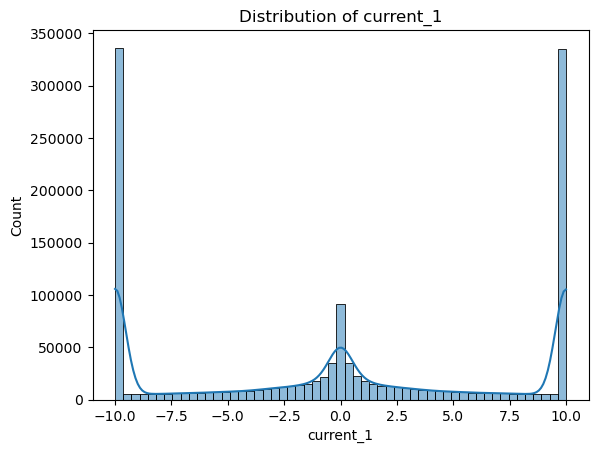

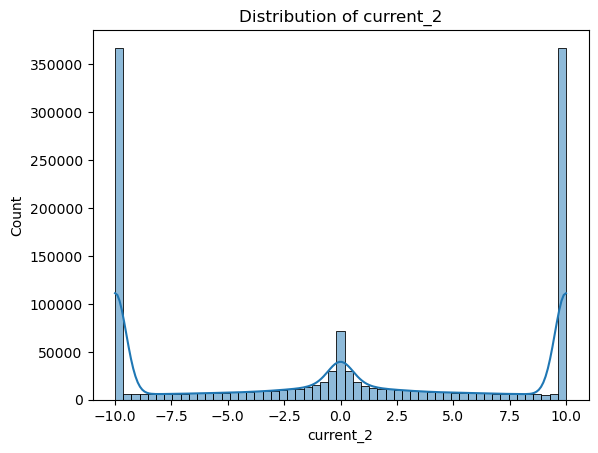

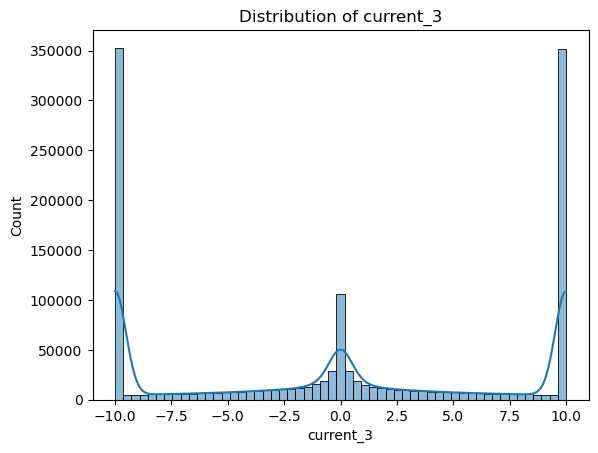

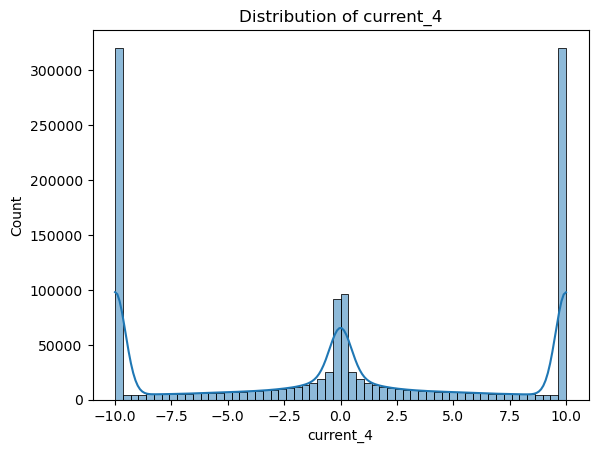

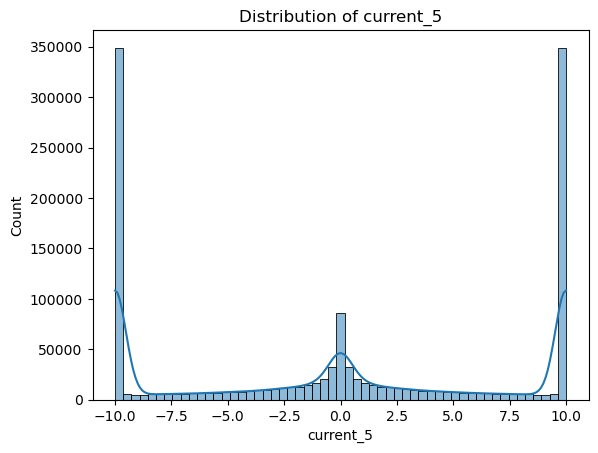

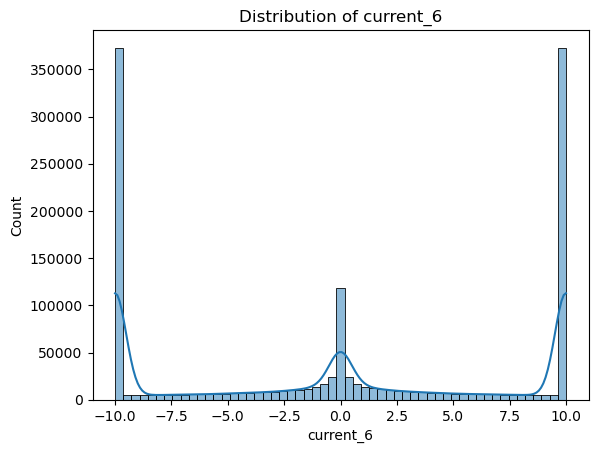

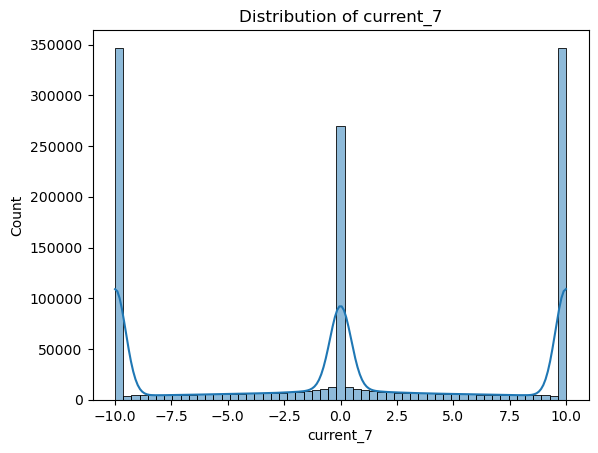

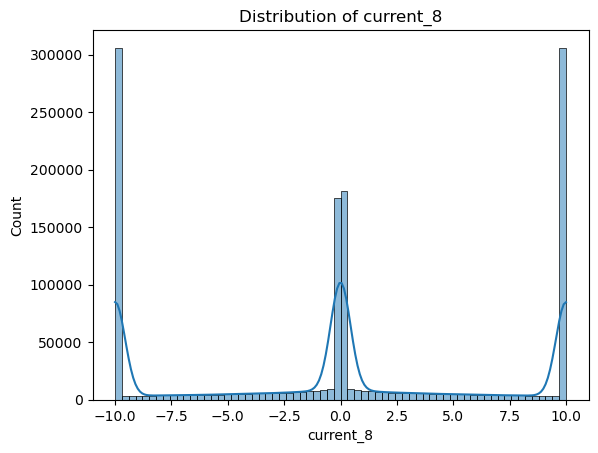

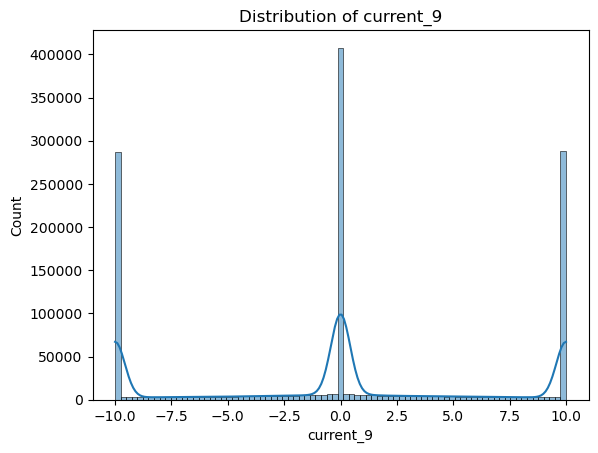

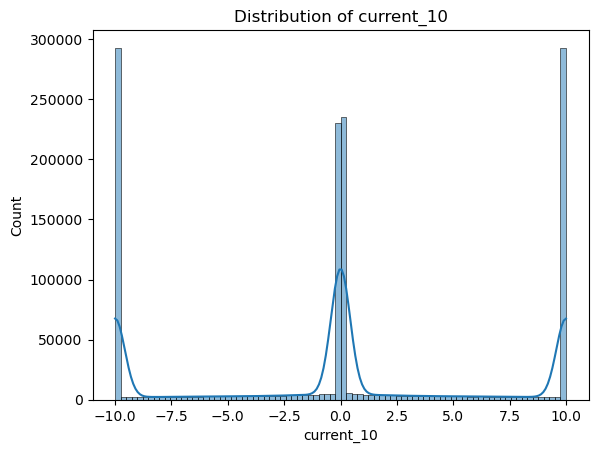

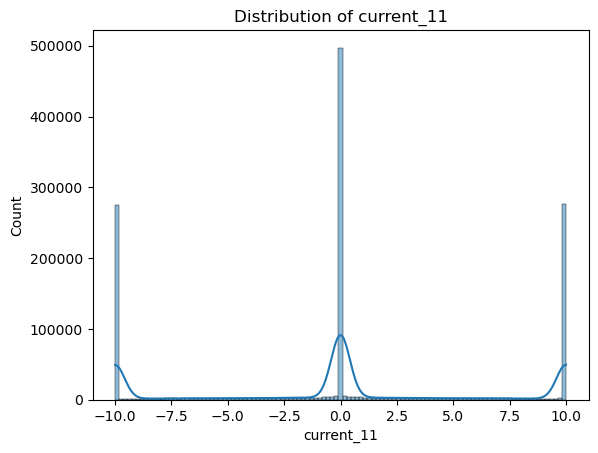

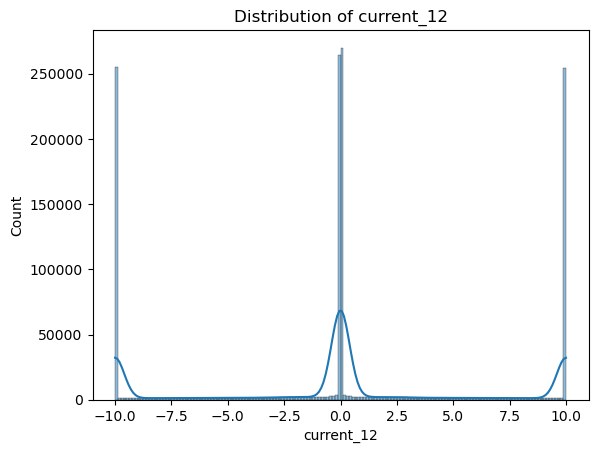

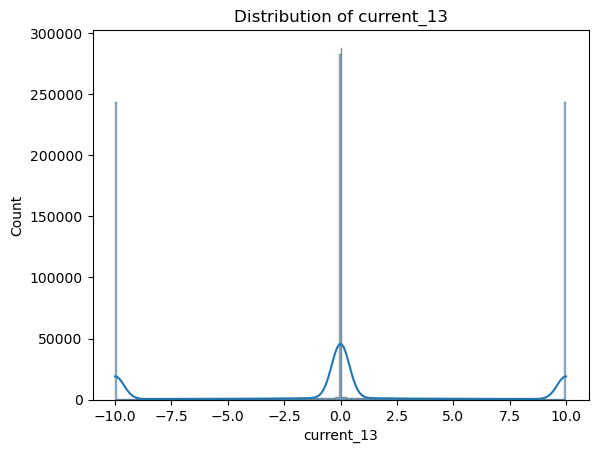

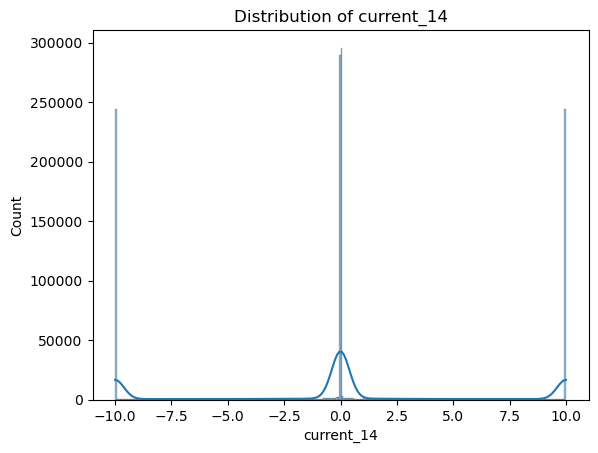

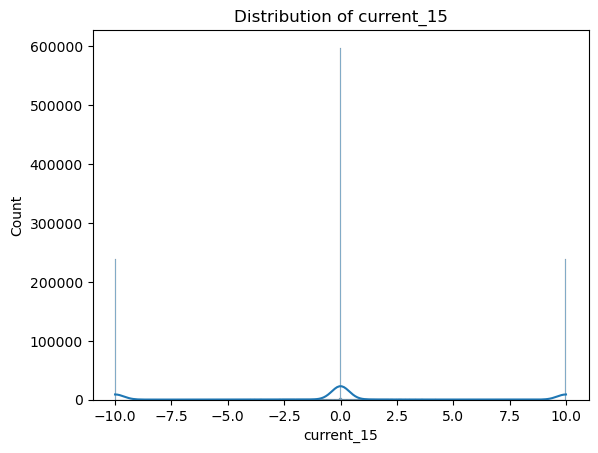

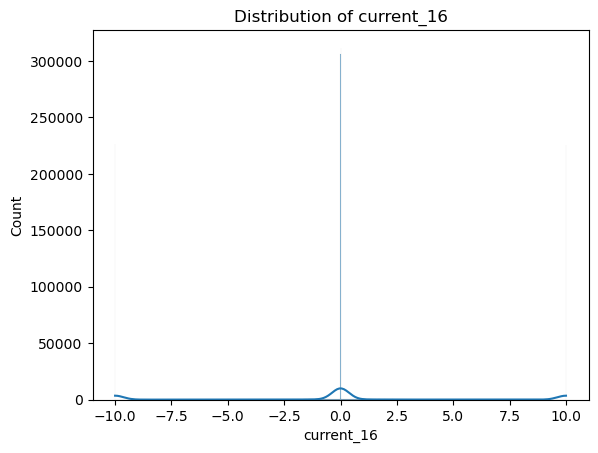

In [33]:
# Verify ranges and plot distributions of current columns
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to current columns still present
valid_current_cols = [c for c in current_cols if c in df.columns]

# Ranges
ranges = df[valid_current_cols].agg(['min', 'max'])
print(ranges)

# Distplot for each current column
for col in valid_current_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


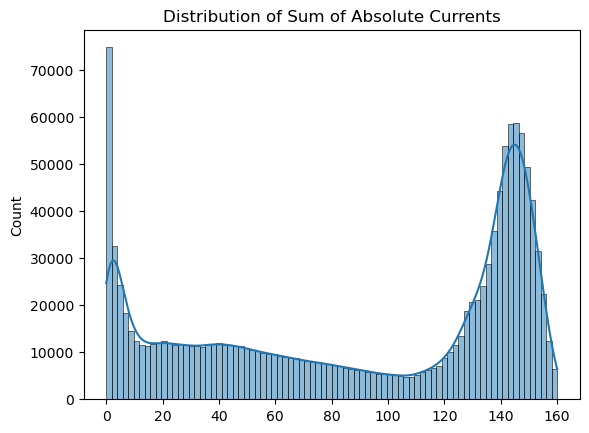

In [37]:
# Temporary: sum of absolute currents + distribution plot
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

valid_current_cols = [c for c in current_cols if c in df.columns]
abs_sum_currents = np.abs(df[valid_current_cols]).sum(axis=1)

# Distribution plot
sns.histplot(abs_sum_currents, kde=True)
plt.title("Distribution of Sum of Absolute Currents")
plt.show()


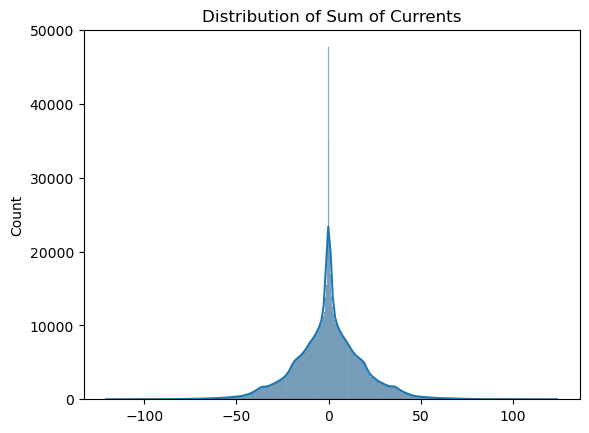

In [38]:
# Temporary: sum of absolute currents + distribution plot
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

valid_current_cols = [c for c in current_cols if c in df.columns]
abs_sum_currents = df[valid_current_cols].sum(axis=1)

# Distribution plot
sns.histplot(abs_sum_currents, kde=True)
plt.title("Distribution of Sum of Currents")
plt.show()


# Input-Target Definition

In [39]:
df.columns

Index(['X', 'Y', 'Z', 'wrench_Fx', 'wrench_Fy', 'wrench_Fz', 'wrench_Tx',
       'wrench_Ty', 'wrench_Tz', 'current_1', 'current_2', 'current_3',
       'current_4', 'current_5', 'current_6', 'current_7', 'current_8',
       'current_9', 'current_10', 'current_11', 'current_12', 'current_13',
       'current_14', 'current_15', 'current_16', 'angle_1_sin', 'angle_1_cos',
       'angle_2_sin', 'angle_2_cos', 'angle_3_sin', 'angle_3_cos', 'r_xyz',
       'sin_w1_s45', 'cos_w1_s45', 'sin_w1_s135', 'cos_w1_s135', 'bias', 's45',
       's135', 'sin_w2_s45', 'cos_w2_s45', 'sin_w2_s135', 'cos_w2_s135'],
      dtype='object')

In [93]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [94]:
# Build input/target blocks for the "Gamma^{-1}(features) @ W -> I" setup

import re
import pandas as pd

# 1) Define canonical column sets
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]

# Current cols in numeric order
current_cols = sorted(
    [c for c in df.columns if c.startswith("current_")],
    key=lambda x: int(re.search(r"\d+", x).group())
)

# 2) Feature columns: everything that's not a wrench or current
feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + current_cols)]

# 3) Build frames (no mutation of df)
X_feat = df.loc[:, feature_cols].apply(pd.to_numeric).copy()
W = df.loc[:, WRENCH_COLS].apply(pd.to_numeric, errors="coerce").copy()
I = df.loc[:, current_cols].apply(pd.to_numeric, errors="coerce").copy()

# 4) Optional: safeties (drop rows with NaNs in W or I only if you want)
# mask_valid = W.notna().all(axis=1) & I.notna().all(axis=1)
# X_feat, W, I = X_feat[mask_valid], W[mask_valid], I[mask_valid]


In [95]:
X_feat.describe()

,X,Y,Z,angle_1_sin,angle_1_cos,angle_2_sin,angle_2_cos,angle_3_sin,angle_3_cos,r_xyz,...,cos_w1_s45,sin_w1_s135,cos_w1_s135,bias,s45,s135,sin_w2_s45,cos_w2_s45,sin_w2_s135,cos_w2_s135
count,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,...,1.287658e+06,1.287658e+06,1.287658e+06,1287658.0,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06
mean,2.101927e-05,-9.624304e-05,5.000000e-03,-1.019840e-05,9.999992e-01,6.368382e-06,9.999992e-01,-3.927008e-06,9.993820e-01,1.182911e-01,...,4.844322e-05,8.421903e-05,8.283367e-05,1.0,8.291697e-05,-5.319124e-05,2.150546e-04,-4.751743e-04,3.131855e-04,2.690876e-04
std,8.917721e-02,8.914123e-02,3.469448e-18,1.235443e-03,5.502319e-07,1.236135e-03,5.499570e-07,3.514757e-02,5.430675e-04,4.394266e-02,...,7.069386e-01,7.071163e-01,7.070979e-01,0.0,8.915681e-02,8.916163e-02,7.070258e-01,7.071881e-01,7.070376e-01,7.071764e-01
min,-1.500000e-01,-1.500000e-01,5.000000e-03,-1.523087e-03,9.999988e-01,-1.523087e-03,9.999988e-01,-5.480367e-02,9.984971e-01,5.000000e-03,...,-9.612389e-01,-9.907880e-01,-9.612389e-01,1.0,-2.121320e-01,-2.121320e-01,-9.998889e-01,-9.962988e-01,-9.998889e-01,-9.962988e-01
25%,-7.500000e-02,-7.500000e-02,5.000000e-03,-1.523087e-03,9.999988e-01,-1.523087e-03,9.999988e-01,-2.741213e-02,9.991546e-01,8.657773e-02,...,-6.555618e-01,-7.534661e-01,-6.555618e-01,1.0,-6.629126e-02,-6.629126e-02,-7.018171e-01,-6.705229e-01,-7.018171e-01,-6.705229e-01
50%,0.000000e+00,0.000000e+00,5.000000e-03,0.000000e+00,9.999988e-01,0.000000e+00,9.999988e-01,0.000000e+00,9.996242e-01,1.223373e-01,...,-1.404775e-01,0.000000e+00,-1.404775e-01,1.0,0.000000e+00,0.000000e+00,0.000000e+00,-4.301852e-02,0.000000e+00,-4.301852e-02
75%,7.500000e-02,7.500000e-02,5.000000e-03,1.523087e-03,1.000000e+00,1.523087e-03,1.000000e+00,2.741213e-02,9.999060e-01,1.512500e-01,...,8.397451e-01,7.534661e-01,8.397451e-01,1.0,6.629126e-02,6.629126e-02,7.018171e-01,7.700470e-01,7.018171e-01,7.700470e-01
max,1.500000e-01,1.500000e-01,5.000000e-03,1.523087e-03,1.000000e+00,1.523087e-03,1.000000e+00,5.480367e-02,1.000000e+00,2.121910e-01,...,1.000000e+00,9.907880e-01,1.000000e+00,1.0,2.121320e-01,2.121320e-01,9.998889e-01,1.000000e+00,9.998889e-01,1.000000e+00


In [96]:
W.describe()

,wrench_Fx,wrench_Fy,wrench_Fz,wrench_Tx,wrench_Ty,wrench_Tz
count,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06
mean,-3.588283e+00,4.353786e+00,1.054874e+01,-1.138089e+00,5.140336e-02,1.717521e+00
std,1.326432e+01,1.491032e+01,4.046822e+01,3.094458e+00,2.415097e+00,2.660243e+00
min,-3.111482e+01,-1.877068e+01,-7.132306e+01,-8.784565e+00,-4.956699e+00,-2.565989e+00
25%,-8.912334e+00,0.000000e+00,0.000000e+00,-2.517007e+00,-4.233964e-02,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.427414e-02
75%,0.000000e+00,1.633448e+01,5.074172e+01,6.004669e-01,1.000000e+00,3.140987e+00
max,2.519888e+01,4.176926e+01,6.791095e+01,3.060779e+00,4.450079e+00,7.497163e+00


In [97]:
I.describe()

,current_1,current_2,current_3,current_4,current_5,current_6,current_7,current_8,current_9,current_10,current_11,current_12,current_13,current_14,current_15,current_16
count,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06,1.287658e+06
mean,-1.363491e-02,-4.005976e-03,-9.721311e-03,-6.405448e-03,-1.913089e-03,7.643466e-03,6.663060e-03,-3.698598e-03,3.674838e-04,5.529176e-04,7.847217e-03,-4.474751e-03,-1.110435e-03,-2.037147e-03,-4.716866e-03,-4.390712e-03
std,7.754680e+00,8.070662e+00,7.904775e+00,7.569230e+00,7.876455e+00,8.056786e+00,7.742967e+00,7.334417e+00,7.119082e+00,7.097665e+00,6.900556e+00,6.681077e+00,6.507181e+00,6.519975e+00,6.425603e+00,6.260852e+00
min,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01,-1.000000e+01
25%,-9.999810e+00,-1.000000e+01,-9.999997e+00,-9.565709e+00,-9.999994e+00,-1.000000e+01,-9.999996e+00,-8.347975e+00,-6.797068e+00,-6.705540e+00,-4.963749e+00,-3.434121e+00,-2.072660e+00,-1.812129e+00,-9.947497e-01,-4.141004e-01
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,9.999524e+00,9.999999e+00,9.999997e+00,9.514990e+00,9.999994e+00,1.000000e+01,9.999996e+00,8.296010e+00,6.770985e+00,6.712163e+00,5.036799e+00,3.381108e+00,2.055374e+00,1.774930e+00,9.386791e-01,3.835209e-01
max,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01


# Model Definition

In [98]:
# TensorFlow surrogate + permutation importance for features → currents
# Assumes X_feat (DataFrame of features) and I (DataFrame of 16 currents) already exist.

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- Prep ---
FEATURE_NAMES = list(X_feat.columns)
X = X_feat.values.astype(np.float32)
Y = I.values.astype(np.float32)

# --- Model builder: small, fast MLP with in-model normalization ---
def build_surrogate(input_dim, output_dim):
    norm = layers.Normalization()
    norm.adapt(X)  # uses current X; move outside if you want to reuse
    inp = keras.Input(shape=(input_dim,))
    x = norm(inp)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(output_dim, activation="linear")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

# --- Train (quick defaults; tune later) ---
def train_surrogate(model, X, Y, epochs=20, batch_size=512, val_split=0.1):
    history = model.fit(X, Y, epochs=epochs, batch_size=batch_size, validation_split=val_split, verbose=1)
    return history

# --- Eval helper: mean MSE across outputs ---
def mse_loss(model, X, Y, batch_size=4096):
    preds = model.predict(X, batch_size=batch_size, verbose=0)
    return float(np.mean((preds - Y) ** 2))

# --- Permutation importance ---
def permutation_importance(model, X, Y, feature_names, n_repeats=5, rng_seed=42, batch_size=4096):
    rng = np.random.default_rng(rng_seed)
    base = mse_loss(model, X, Y, batch_size=batch_size)
    importances = np.zeros(len(feature_names), dtype=np.float64)

    X_work = X.copy()
    for j in range(len(feature_names)):
        deltas = []
        for _ in range(n_repeats):
            col = X_work[:, j].copy()
            rng.shuffle(X_work[:, j])             # permute one feature
            m = mse_loss(model, X_work, Y, batch_size=batch_size)
            deltas.append(m - base)
            X_work[:, j] = col                    # restore
        importances[j] = np.mean(deltas)

    imp_df = pd.DataFrame({"feature": feature_names, "perm_importance": importances})
    imp_df.sort_values("perm_importance", ascending=False, inplace=True)
    imp_df.reset_index(drop=True, inplace=True)
    return imp_df, base




In [51]:
model = build_surrogate(X.shape[1], Y.shape[1])
_ = train_surrogate(model, X, Y, epochs=20)
imp_df, base_mse = permutation_importance(model, X, Y, FEATURE_NAMES, n_repeats=5)
print("Baseline MSE:", base_mse)
print(imp_df.head(15))


Epoch 1/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 52.0252 - val_loss: 55.1333
Epoch 2/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 920us/step - loss: 51.3532 - val_loss: 54.8015
Epoch 3/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 925us/step - loss: 51.0739 - val_loss: 54.6180
Epoch 4/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 926us/step - loss: 50.9117 - val_loss: 54.5261
Epoch 5/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 928us/step - loss: 50.8116 - val_loss: 54.4648
Epoch 6/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 897us/step - loss: 50.7457 - val_loss: 54.4131
Epoch 7/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 935us/step - loss: 50.6926 - val_loss: 54.4349
Epoch 8/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 923us/step - loss: 50.6505 - val_loss: 54.3543
Epoch 9/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 910us/step - loss: 50.6167 - val_loss: 54.3554
Epoch 10/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 939us/step - loss: 50.5870 - val_loss: 54.3341
Epoch 11/20
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 908us/step - loss: 50.5601 - val_lo

Model: "gamma_inv_wrench_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━
┃ Layer (type)                            ┃ Output Shape                      ┃               Param # ┃ Connected t
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━
│ features (InputLayer)                   │ (None, 21)                        │                     0 │ -          
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ dense_10 (Dense)                        │ (None, 128)                       │                 2,816 │ features[0]
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ dense_11 (Dense)                        │ (None, 64)                        │                 8,256 │ dense_10[0]
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ gamma_flat (Dense)                      │ (None, 96)                        │                 6,240 │ dense_11[0]
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ wrench (InputLayer)                     │ (None, 6)                         │                     0 │ -          
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ Gamma_inv (Reshape)                     │ (None, 16, 6)                     │                     0 │ gamma_flat[
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ wrench_vec (Reshape)                    │ (None, 6, 1)                      │                     0 │ wrench[0][0
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ matmul (Lambda)                         │ (None, 16, 1)                     │                     0 │ Gamma_inv[0
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ currents (Reshape)                      │ (None, 16)                        │                     0 │ matmul[0][0
└─────────────────────────────────────────┴───────────────────────────────────┴───────────────────────┴────────────

 Total params: 17,312 (67.62 KB)

 Trainable params: 17,312 (67.62 KB)

 Non-trainable params: 0 (0.00 B)

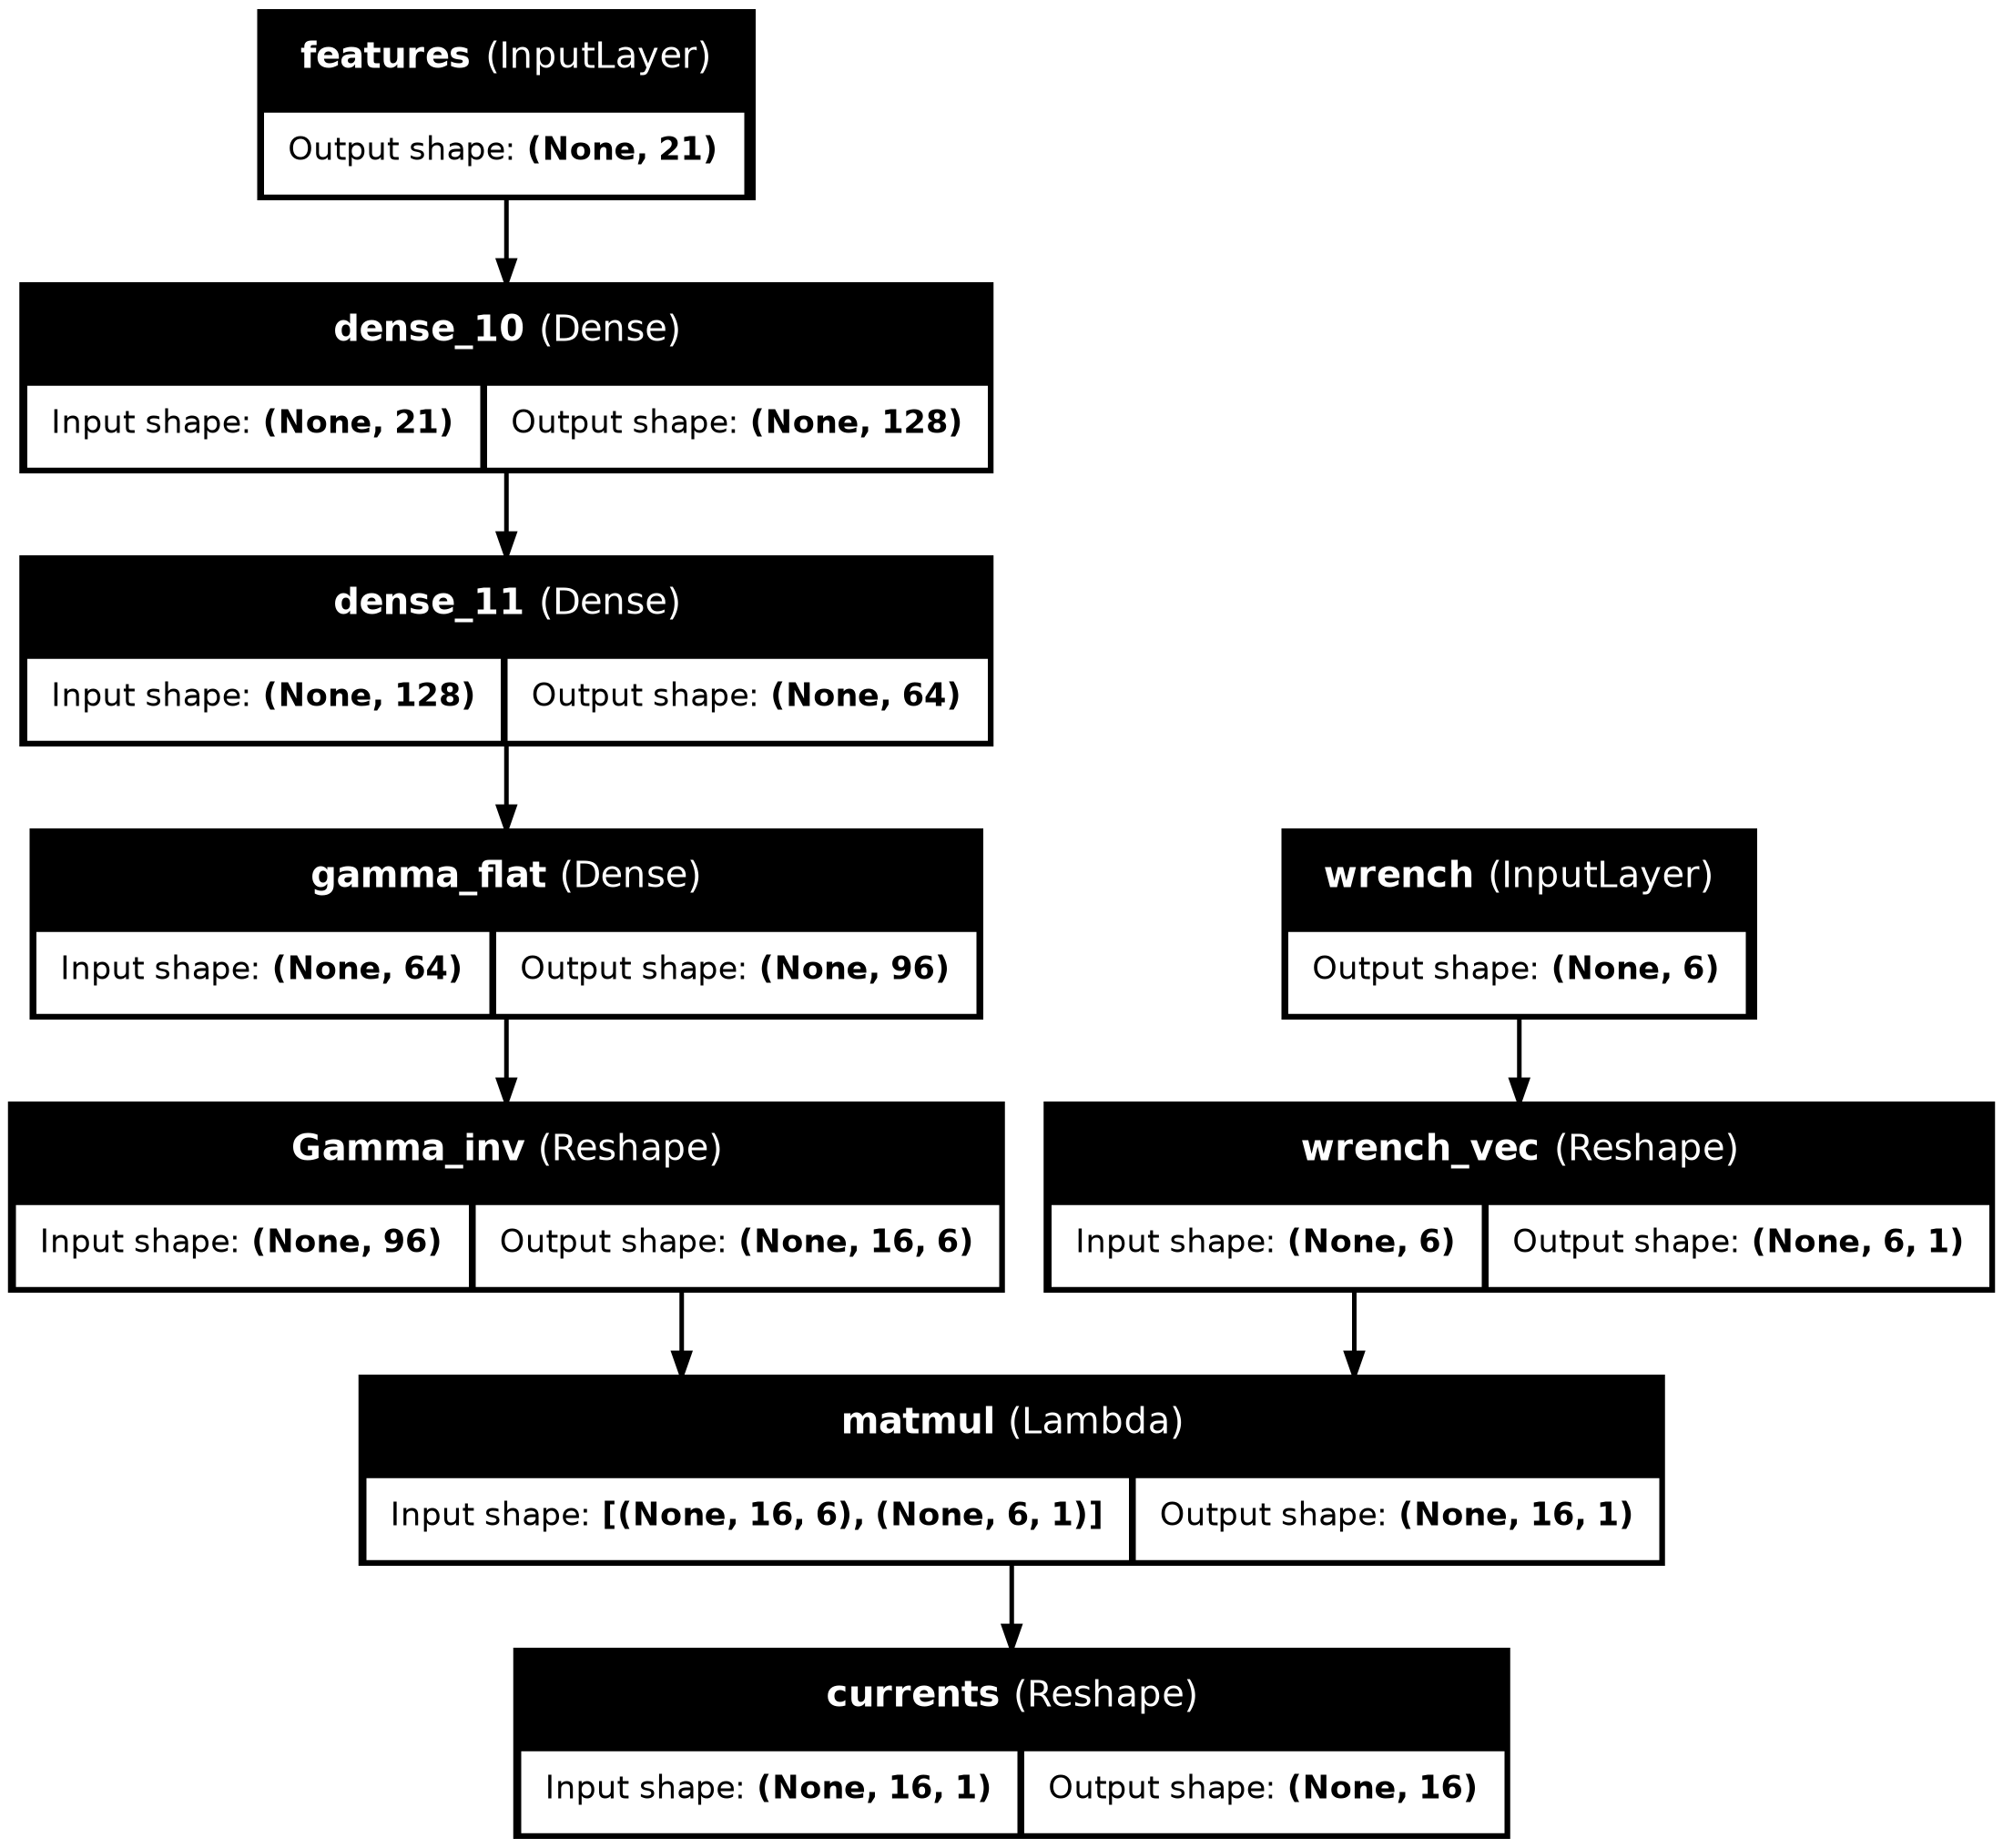

In [54]:
# Build + inspect model structure
model = build_gamma_inv_model(n_features=X_feat.shape[1])

# 1) Console summary (layers, shapes, params)
model.summary(line_length=140, expand_nested=True)

# 2) Graph image (requires pydot + graphviz installed)
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    to_file="gamma_inv_model.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=180,
    rankdir="TB"
)


In [100]:
# Fit the physics-aware model (features → Γ⁻¹ → × wrench → currents)

import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# 0) Numpy arrays (float32)
X_np = X_feat.values.astype(np.float32)
W_np = W[WRENCH_COLS].values.astype(np.float32)   # order matters
Y_np = I.values.astype(np.float32)

# 1) Train/val split (keep pairs aligned)
X_tr, X_va, W_tr, W_va, Y_tr, Y_va = train_test_split(
    X_np, W_np, Y_np, test_size=0.1, random_state=42
)

# 2) Build model
model = build_gamma_inv_model(n_features=X_np.shape[1])

# 3) Callbacks + fit (shows progress)
cbs = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]
history = model.fit(
    [X_tr, W_tr], Y_tr,
    validation_data=([X_va, W_va], Y_va),
    epochs=50,
    batch_size=512,
    verbose=1,
    callbacks=cbs
)


Epoch 1/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 53.0949 - val_loss: 52.7278 - learning_rate: 0.0010
Epoch 2/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 963us/step - loss: 52.7527 - val_loss: 52.7106 - learning_rate: 0.0010
Epoch 3/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 993us/step - loss: 52.7468 - val_loss: 52.7377 - learning_rate: 0.0010
Epoch 4/50
2248/2264 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - loss: 52.7318
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 970us/step - loss: 52.7430 - val_loss: 52.7159 - learning_rate: 0.0010
Epoch 5/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 989us/step - loss: 52.7298 - val_loss: 52.7141 - learning_rate: 5.0000e-04
Epoch 6/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 998us/step - loss: 52.7284 - val_loss: 52.6982 - learning_rate: 5.0000e-04
Epoch 7/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 977us/step - loss: 52.7279 - val_loss: 52.6986 - learning_rate: 5.0000e-04
Epoch 8/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

2025-08-14 17:57:52.028007: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 28 bytes spill stores, 28 bytes spill loads

2025-08-14 17:57:52.058661: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 124 bytes spill stores, 124 bytes spill loads

2025-08-14 17:57:52.691969: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 12 bytes spill stores, 12 bytes spill loads

2025-08-14 17:57:52.821105: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 132 bytes spill stores, 132 bytes spill loads

2025-08-14 17:57:53.330854: I external/local

Test MSE (overall): 52.77633285522461
Test MSE per current (1..16): [60.08917  65.209206 62.492992 57.429333 62.067085 65.056435 59.990154
 53.816032 50.694252 50.31039  47.625244 44.664364 42.366886 42.438385
 41.093193 39.05743 ]


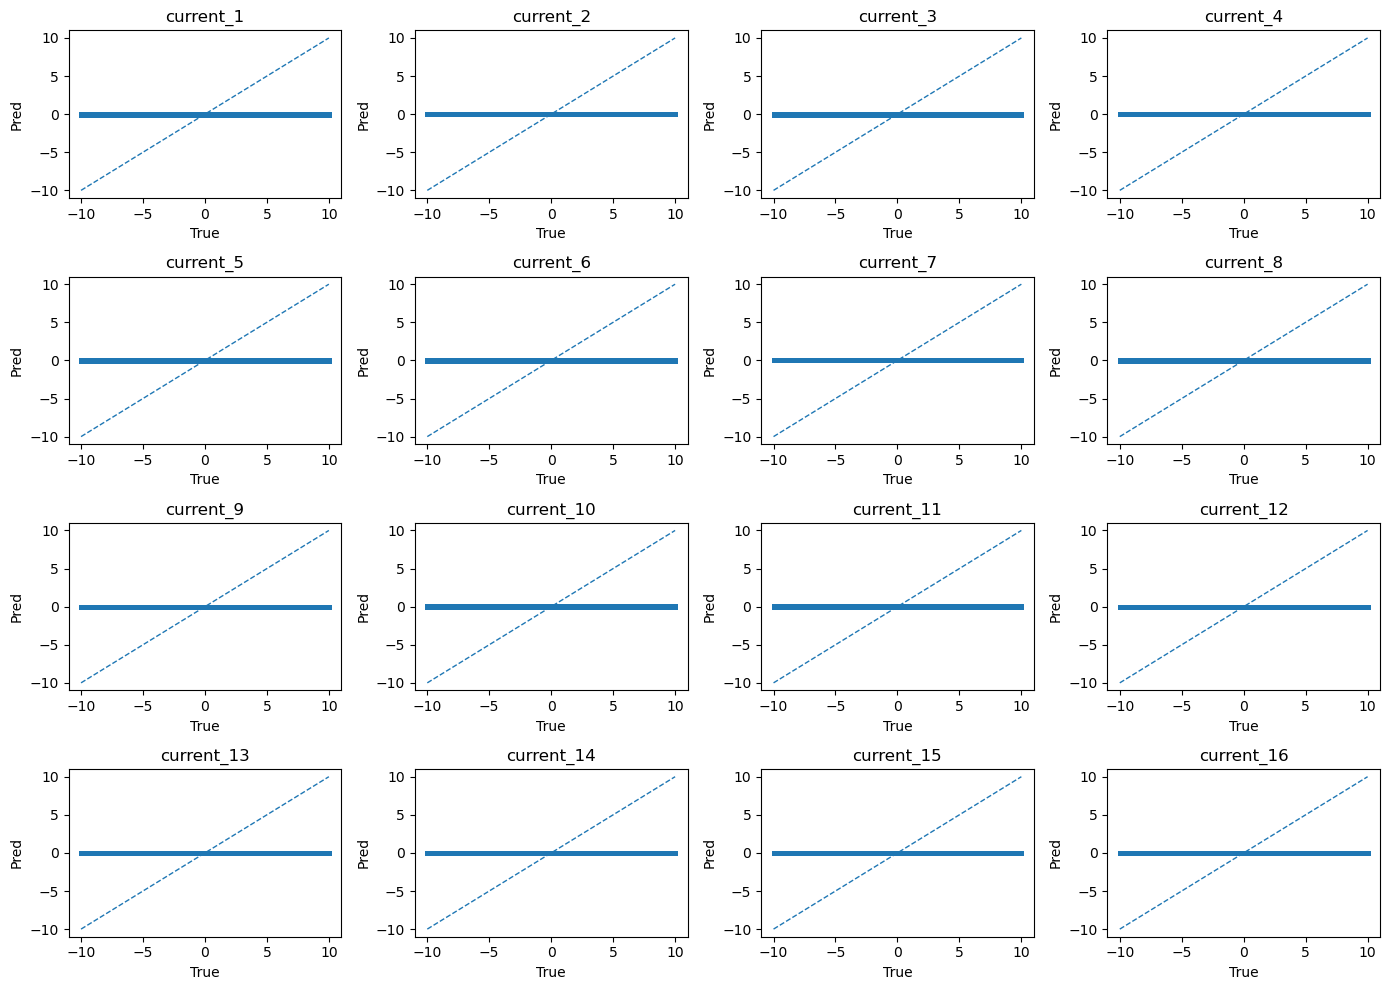

In [56]:
# Predict on a held-out test split and plot results

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1) Make a disjoint test split from the full arrays (no retrain)
X_te_split, X_te, W_te_split, W_te, Y_te_split, Y_te = train_test_split(
    X_np, W_np, Y_np, test_size=0.10, random_state=7
)

# 2) Predict
Y_pred = model.predict([X_te, W_te], batch_size=4096, verbose=0)

# 3) Quick metrics
mse_overall = np.mean((Y_pred - Y_te) ** 2)
mse_per_current = np.mean((Y_pred - Y_te) ** 2, axis=0)
print("Test MSE (overall):", float(mse_overall))
print("Test MSE per current (1..16):", np.round(mse_per_current, 6))

# 4) Parity plots (y_pred vs y_true) for all 16 currents
n_out = Y_te.shape[1]
cols = 4
rows = int(np.ceil(n_out / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes = axes.ravel()

minv = np.minimum(Y_te.min(), Y_pred.min())
maxv = np.maximum(Y_te.max(), Y_pred.max())

for i in range(n_out):
    ax = axes[i]
    ax.scatter(Y_te[:, i], Y_pred[:, i], s=6, alpha=0.6)
    ax.plot([minv, maxv], [minv, maxv], linestyle="--", linewidth=1)
    ax.set_title(f"current_{i+1}")
    ax.set_xlabel("True")
    ax.set_ylabel("Pred")

# Hide any unused subplots
for j in range(n_out, rows * cols):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()


### REgression test

In [101]:
def build_linear_gamma_inv_model(n_features: int):
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    feat_in = keras.Input(shape=(n_features,), name="features")
    wrench_in = keras.Input(shape=(6,), name="wrench")

    # Linear regression head (no hidden layers)
    gamma_flat = layers.Dense(16 * 6, activation="linear", name="gamma_flat")(feat_in)
    gamma = layers.Reshape((16, 6), name="Gamma_inv")(gamma_flat)

    # Physics step: multiply Γ⁻¹ by wrench
    wrench_vec = layers.Reshape((6, 1), name="wrench_vec")(wrench_in)
    currents_3d = layers.Lambda(lambda t: tf.matmul(t[0], t[1]), name="matmul")([gamma, wrench_vec])
    currents = layers.Reshape((16,), name="currents")(currents_3d)

    model = keras.Model(inputs=[feat_in, wrench_in], outputs=currents, name="linear_gamma_inv_model")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

# Example usage:
model = build_linear_gamma_inv_model(X_np.shape[1])
model.fit([X_tr, W_tr], Y_tr, validation_data=([X_va, W_va], Y_va), epochs=50, batch_size=512, verbose=1)


Epoch 1/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 58.7250 - val_loss: 52.8202
Epoch 2/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 877us/step - loss: 52.8534 - val_loss: 52.8348
Epoch 3/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 879us/step - loss: 52.8581 - val_loss: 52.8104
Epoch 4/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 887us/step - loss: 52.8560 - val_loss: 52.8738
Epoch 5/50
 924/2264 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - loss: 52.8295

KeyboardInterrupt: 

/home/alireza-linux/.local/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:34:33] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alireza-linux/.local/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:34:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_32476/155189183.py:39: UserWarning: [18:34:35] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  scores = model.get_booster().get_score(importance_type="gain")
/home/alireza-linux/.local/lib/python3.12/site-packages/xgb


Top 15 features by mean gain across all currents:
               current_1    current_2    current_3     current_4    current_5  \
angle_1_cos  9227.342773  3958.745605  7312.374023  11974.037109  4577.690918   
angle_1_sin  3001.683838  5423.379883  5622.176758   3570.340576  4379.612793   
angle_2_cos  3481.883057  1589.193604  7316.379395   6157.527344  4567.917969   
angle_2_sin  1060.293579  2600.418457  3919.321289   2025.769775  4705.348145   
cos_w1_s135  8873.539062  1505.034058  3097.901855   3291.717285  1898.320435   
angle_3_cos  3859.207520  3118.235840  2861.015869   2978.646484  2998.513672   
cos_w1_s45   2322.678223  1449.155273  3251.983398   3623.431641  4333.874023   
sin_w1_s45   1158.078979  3711.910889  2073.741943   1096.911743  2153.693604   
sin_w1_s135  2402.998535  1940.892212  1100.024048   1271.551147  1152.959473   
angle_3_sin  1558.882568  2137.379150  2007.006714   1648.984497  1992.949341   
X             782.993835  1137.330444   862.967285   1036.

/tmp/ipykernel_32476/155189183.py:39: UserWarning: [18:35:18] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  scores = model.get_booster().get_score(importance_type="gain")


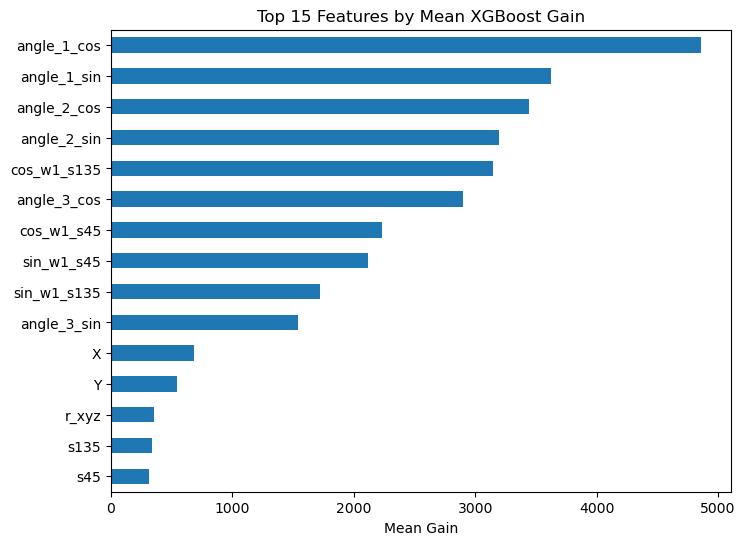

In [67]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import re

# --- Prepare column lists ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]

current_cols = sorted(
    [c for c in df.columns if c.startswith("current_")],
    key=lambda x: int(re.search(r"\d+", x).group())
)

feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + current_cols)]

X_feat = df[feature_cols]
I = df[current_cols]

# --- XGBoost importance loop ---
xgb_importances = pd.DataFrame(0.0, index=feature_cols, columns=current_cols)

for curr_col in current_cols:
    model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="gpu_hist",        # GPU train
        predictor="gpu_predictor",     # GPU predict
        random_state=42,
        eval_metric="rmse"             # For early stopping
    )
    model.fit(
        X_feat, I[curr_col],
        eval_set=[(X_feat, I[curr_col])],
        verbose=False
    )
    scores = model.get_booster().get_score(importance_type="gain")
    for feat, val in scores.items():
        xgb_importances.loc[feat, curr_col] = val

# --- Aggregate and display ---
xgb_importances['mean_gain'] = xgb_importances.mean(axis=1)
xgb_importances.sort_values('mean_gain', ascending=False, inplace=True)

print("\nTop 15 features by mean gain across all currents:")
print(xgb_importances.head(15))

# --- Plot ---
plt.figure(figsize=(8, 6))
xgb_importances['mean_gain'].head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Features by Mean XGBoost Gain")
plt.xlabel("Mean Gain")
plt.show()


### One coil prediction

In [102]:
# --- Choose the coil ---
coil_target = "current_7"  # change this to the coil you want

# --- Define column sets ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
current_cols = [c for c in df.columns if c.startswith("current_")]
feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + current_cols)]

# --- Build input and target arrays ---
X_feat = df[feature_cols].astype("float32")             # model inputs (pose/features)
W = df[WRENCH_COLS].astype("float32")                   # wrench vectors
y_target = df[coil_target].astype("float32")            # one coil's current

print(f"Target coil: {coil_target}")
print(f"Features: {len(feature_cols)} cols")
print(f"Sample shape: X_feat={X_feat.shape}, W={W.shape}, y_target={y_target.shape}")


Target coil: current_7
Features: 21 cols
Sample shape: X_feat=(1287658, 21), W=(1287658, 6), y_target=(1287658,)


In [103]:
def build_single_coil_gamma_inv_model(n_features: int):
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    feat_in = keras.Input(shape=(n_features,), name="features")
    wrench_in = keras.Input(shape=(6,), name="wrench")

    # Simple dense head: features → (1x6) coefficients
    x = layers.Dense(64, activation="relu")(feat_in)
    x = layers.Dense(32, activation="relu")(x)
    gamma_row_flat = layers.Dense(6, activation="linear", name="gamma_row")(x)  # (None, 6)

    # Multiply by wrench (6x1)
    wrench_vec = layers.Reshape((6, 1), name="wrench_vec")(wrench_in)            # (None, 6, 1)
    gamma_row_mat = layers.Reshape((1, 6), name="gamma_row_mat")(gamma_row_flat) # (None, 1, 6)
    current_pred = layers.Lambda(lambda t: tf.matmul(t[0], t[1]), name="matmul")([gamma_row_mat, wrench_vec])
    current_pred = layers.Reshape((), name="current_scalar")(current_pred)       # (None,)

    model = keras.Model(inputs=[feat_in, wrench_in], outputs=current_pred, name="single_coil_gamma_inv")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


In [104]:
from sklearn.model_selection import train_test_split
from tensorflow import keras
import numpy as np

# --- Choose target coil ---
coil_target = "current_16"  # change to whichever coil you want

# --- Prepare inputs/target ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
current_cols = [c for c in df.columns if c.startswith("current_")]
feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + current_cols)]

X_feat = df[feature_cols].astype("float32")
W = df[WRENCH_COLS].astype("float32")
y_target = df[coil_target].astype("float32")

# --- Train/validation split ---
X_tr, X_va, W_tr, W_va, y_tr, y_va = train_test_split(
    X_feat.values, W.values, y_target.values,
    test_size=0.1, random_state=42
)

# --- Build model ---
model = build_single_coil_gamma_inv_model(n_features=X_feat.shape[1])

# --- Callbacks ---
cbs = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-3, verbose=1)
]

# --- Train ---
history = model.fit(
    [X_tr, W_tr], y_tr,
    validation_data=([X_va, W_va], y_va),
    epochs=50,
    batch_size=512,
    verbose=1,
    callbacks=cbs
)


Epoch 1/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 41.2983 - val_loss: 39.4695 - learning_rate: 0.0010
Epoch 2/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 952us/step - loss: 39.2489 - val_loss: 39.2927 - learning_rate: 0.0010
Epoch 3/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 960us/step - loss: 39.1964 - val_loss: 39.2563 - learning_rate: 0.0010
Epoch 4/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 972us/step - loss: 39.1645 - val_loss: 39.2589 - learning_rate: 0.0010
Epoch 5/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 954us/step - loss: 39.1389 - val_loss: 39.2547 - learning_rate: 0.0010
Epoch 6/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 950us/step - loss: 39.1247 - val_loss: 39.2178 - learning_rate: 0.0010
Epoch 7/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 925us/step - loss: 39.1181 - val_loss: 39.2298 - learning_rate: 0.0010
Epoch 8/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 937us/step - loss: 39.1123 - val_loss: 39.2259 - learning_rate: 0.0010
Epoch 9/50
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 940us/step - loss: 39.1057 - 

Model: "single_coil_gamma_inv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━
┃ Layer (type)                            ┃ Output Shape                      ┃               Param # ┃ Connected t
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━
│ features (InputLayer)                   │ (None, 21)                        │                     0 │ -          
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ dense_20 (Dense)                        │ (None, 64)                        │                 1,408 │ features[0]
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ dense_21 (Dense)                        │ (None, 32)                        │                 2,080 │ dense_20[0]
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ gamma_row (Dense)                       │ (None, 6)                         │                   198 │ dense_21[0]
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ wrench (InputLayer)                     │ (None, 6)                         │                     0 │ -          
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ gamma_row_mat (Reshape)                 │ (None, 1, 6)                      │                     0 │ gamma_row[0
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ wrench_vec (Reshape)                    │ (None, 6, 1)                      │                     0 │ wrench[0][0
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ matmul (Lambda)                         │ (None, 1, 1)                      │                     0 │ gamma_row_m
│                                         │                                   │                       │ wrench_vec[
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ current_scalar (Reshape)                │ (None)                            │                     0 │ matmul[0][0
└─────────────────────────────────────────┴───────────────────────────────────┴───────────────────────┴────────────

 Total params: 11,060 (43.21 KB)

 Trainable params: 3,686 (14.40 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,374 (28.81 KB)

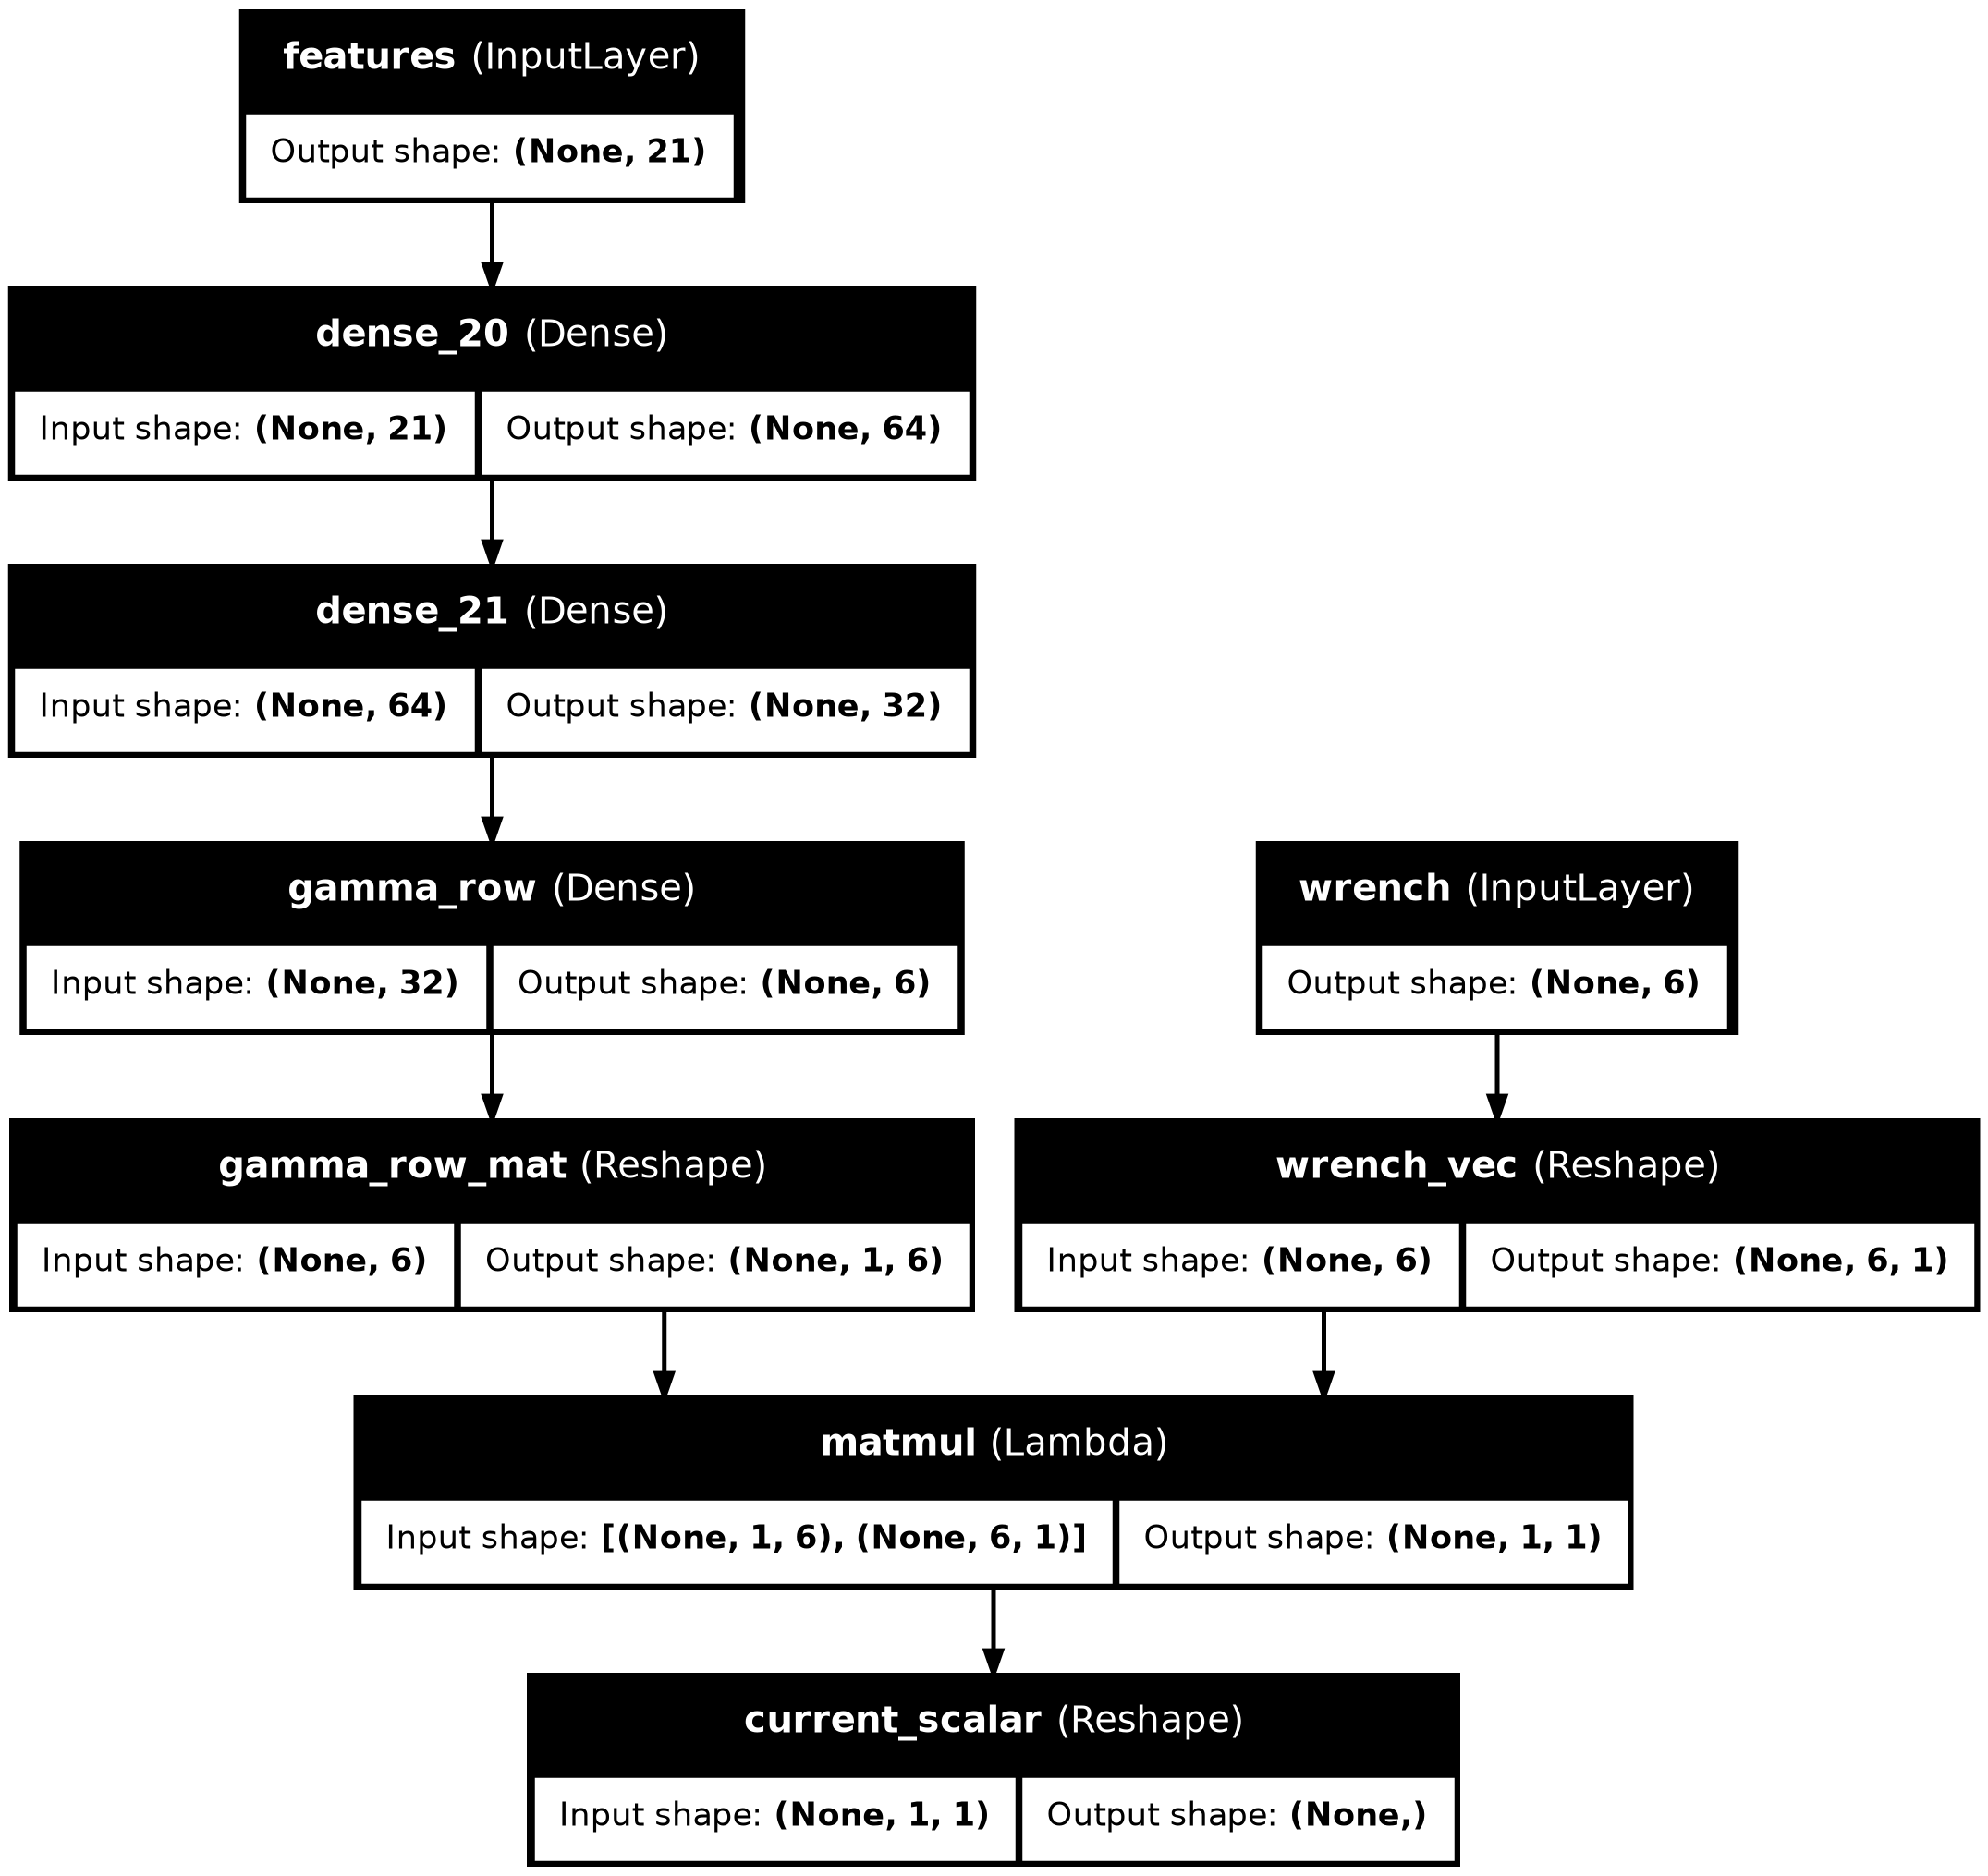

In [75]:
# 1) Console summary (layers, shapes, params)
model.summary(line_length=140, expand_nested=True)

# 2) Graph image (requires pydot + graphviz installed)
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    to_file="gamma_inv_model.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=180,
    rankdir="TB"
)


In [82]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

class Sine(layers.Layer):
    def __init__(self, w0=1.0, **kwargs):
        super().__init__(**kwargs)
        self.w0 = w0
    def call(self, inputs):
        return tf.sin(self.w0 * inputs)

def build_single_coil_siren_model(n_features: int, w0=30.0):
    feat_in = keras.Input(shape=(n_features,), name="features")
    wrench_in = keras.Input(shape=(6,), name="wrench")

    # First SIREN layer with special init
    init_first = keras.initializers.RandomUniform(
        minval=-1/n_features, maxval=1/n_features
    )
    x = layers.Dense(64, kernel_initializer=init_first)(feat_in)
    x = Sine(w0=w0)(x)

    # Hidden SIREN layers
    for _ in range(4):
        x = layers.Dense(64, kernel_initializer="lecun_normal")(x)
        x = Sine(w0=1.0)(x)

    # Output: 6 coefficients for this coil's row
    gamma_row_flat = layers.Dense(6, activation="linear", name="gamma_row")(x)

    # Physics multiply
    wrench_vec = layers.Reshape((6, 1), name="wrench_vec")(wrench_in)
    gamma_row_mat = layers.Reshape((1, 6), name="gamma_row_mat")(gamma_row_flat)
    current_pred = layers.Lambda(lambda t: tf.matmul(t[0], t[1]), name="matmul")([gamma_row_mat, wrench_vec])
    current_pred = layers.Reshape((), name="current_scalar")(current_pred)

    model = keras.Model(inputs=[feat_in, wrench_in], outputs=current_pred, name="single_coil_siren")
    model.compile(optimizer=keras.optimizers.Adam(1e-4), loss="mse")  # Lower LR for SIREN
    return model


In [83]:
from sklearn.model_selection import train_test_split
from tensorflow import keras

# --- Choose target coil ---
coil_target = "current_16"  # change this to whichever coil you want

# --- Prepare inputs/target ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
current_cols = [c for c in df.columns if c.startswith("current_")]
feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + current_cols)]

X_feat = df[feature_cols].astype("float32")
W = df[WRENCH_COLS].astype("float32")
y_target = df[coil_target].astype("float32")

# --- Train/validation split ---
X_tr, X_va, W_tr, W_va, y_tr, y_va = train_test_split(
    X_feat.values, W.values, y_target.values,
    test_size=0.1, random_state=42
)

# --- Build SIREN model ---
model = build_single_coil_siren_model(n_features=X_feat.shape[1], w0=30.0)

# --- Callbacks ---
cbs = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# --- Train ---
history = model.fit(
    [X_tr, W_tr], y_tr,
    validation_data=([X_va, W_va], y_va),
    epochs=400,            # SIREN sometimes needs more epochs
    batch_size=512,
    verbose=1,
    callbacks=cbs
)


Epoch 1/400
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 46.2157 - val_loss: 40.0440 - learning_rate: 1.0000e-04
Epoch 2/400
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 39.8428 - val_loss: 39.8267 - learning_rate: 1.0000e-04
Epoch 3/400
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 39.5672 - val_loss: 39.5671 - learning_rate: 1.0000e-04
Epoch 4/400
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 39.4381 - val_loss: 39.3495 - learning_rate: 1.0000e-04
Epoch 5/400
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 39.3609 - val_loss: 39.3015 - learning_rate: 1.0000e-04
Epoch 6/400
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 39.2999 - val_loss: 39.2392 - learning_rate: 1.0000e-04
Epoch 7/400
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 39.2600 - val_loss: 39.1833 - learning_rate: 1.0000e-04
Epoch 8/400
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 39.2225 - val_loss: 39.1946 - learning_rate: 1.0000e-04
Epoch 9/400
2262/2264 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

Validation MSE: 34.609981


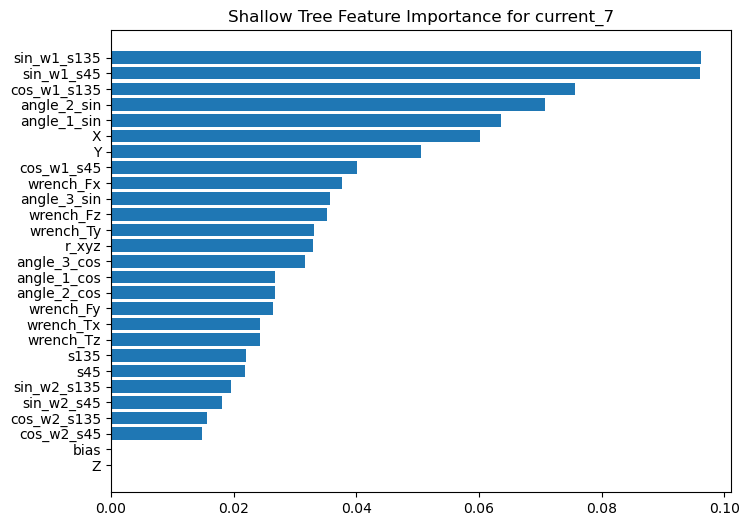

In [90]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# --- Choose coil ---
coil_target = "current_7"  # pick your coil

# --- Prepare data ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
current_cols = [c for c in df.columns if c.startswith("current_")]
feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + current_cols)]

# Combine features + wrench
X_all = np.hstack([df[feature_cols].values, df[WRENCH_COLS].values])
y_target = df[coil_target].values

# --- Split ---
X_tr, X_va, y_tr, y_va = train_test_split(X_all, y_target, test_size=0.1, random_state=42)

# --- Shallow tree ---
tree = DecisionTreeRegressor(
    max_depth=1024,        # shallow
    min_samples_leaf=3,
    random_state=42
)
tree.fit(X_tr, y_tr)

# --- Evaluate ---
y_pred = tree.predict(X_va)
mse_val = mean_squared_error(y_va, y_pred)
print(f"Validation MSE: {mse_val:.6f}")

# --- Optional: Feature importance ---
import matplotlib.pyplot as plt
importances = tree.feature_importances_
all_feature_names = feature_cols + WRENCH_COLS
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.barh([all_feature_names[i] for i in sorted_idx], importances[sorted_idx])
plt.gca().invert_yaxis()
plt.title(f"Shallow Tree Feature Importance for {coil_target}")
plt.show()


In [92]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import numpy as np

# --- Choose coil ---
coil_target = "current_7"

# --- Prepare data ---
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
current_cols = [c for c in df.columns if c.startswith("current_")]
feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + current_cols)]

X_feat = df[feature_cols].values
W_mat = df[WRENCH_COLS].values
curr = df[coil_target].values.reshape(-1, 1)

# --- Solve for per-sample 1×6 gamma_row via least squares ---
# W_mat: (n_samples, 6), curr: (n_samples, 1)
# gamma_row: (n_samples, 6)
gamma_rows = []
for i in range(len(W_mat)):
    w = W_mat[i].reshape(6, 1)
    # pseudo-inverse multiplication to solve gamma_row * w = current
    coeffs, _, _, _ = np.linalg.lstsq(w.T, curr[i], rcond=None)
    gamma_rows.append(coeffs.flatten())
gamma_rows = np.array(gamma_rows)

# --- Split ---
X_tr, X_va, G_tr, G_va, W_tr, W_va, y_tr, y_va = train_test_split(
    X_feat, gamma_rows, W_mat, curr, test_size=0.1, random_state=42
)

# --- Multi-output regression tree ---
tree = DecisionTreeRegressor(max_depth=1024, min_samples_leaf=3, random_state=42)
tree.fit(X_tr, G_tr)

# --- Predict currents via physics multiply ---
G_pred = tree.predict(X_va)                        # (n_samples, 6)
y_pred = np.einsum('ij,ij->i', G_pred, W_va)        # dot product row-wise

# --- Evaluate ---
from sklearn.metrics import mean_squared_error
mse_val = mean_squared_error(y_va, y_pred)
print(f"Validation MSE: {mse_val:.6f}")


Validation MSE: 470.139321


In [105]:
# W norm and y distribution checks
import numpy as np

W_np = W.values.astype(np.float32)
y_np = y_target.values.astype(np.float32) if hasattr(y_target, "values") else y_target.astype(np.float32)

w_norm = np.linalg.norm(W_np, axis=1)
print(
    "W norm: min/median/max = ",
    float(w_norm.min()), float(np.median(w_norm)), float(w_norm.max()),
    "| frac(|W|<1e-3):", float((w_norm < 1e-3).mean())
)
print(
    "y stats: mean/std/min/max = ",
    float(y_np.mean()), float(y_np.std()), float(y_np.min()), float(y_np.max())
)


W norm: min/median/max =  1.0 29.034086227416992 74.95047760009766 | frac(|W|<1e-3): 0.0
y stats: mean/std/min/max =  -0.004390711896121502 6.260849952697754 -10.0 10.0


sdfghjk

In [106]:
# 1) Normalize features, wrench, and target; add wrench bias
from sklearn.model_selection import train_test_split
import numpy as np

# Feature/Wrench/Target arrays
X = df[feature_cols].values.astype("float32")
W6 = df[["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]].values.astype("float32")
y = df[coil_target].values.astype("float32")

# Standardization
X_mean, X_std = X.mean(0), X.std(0) + 1e-8
W_mean, W_std = W6.mean(0), W6.std(0) + 1e-8
y_mean, y_std = y.mean(), y.std() + 1e-8

Xn = (X - X_mean) / X_std
Wn6 = (W6 - W_mean) / W_std
Wn = np.hstack([Wn6, np.ones((len(W6), 1), dtype=np.float32)])  # bias term
yn = (y - y_mean) / y_std

X_tr, X_va, W_tr, W_va, y_tr, y_va = train_test_split(Xn, Wn, yn, test_size=0.1, random_state=42)


In [107]:
# 2) SIREN with correct init + 7-d wrench (bias)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

class Sine(layers.Layer):
    def __init__(self, w0=1.0, **kwargs):
        super().__init__(**kwargs); self.w0 = w0
    def call(self, x): return tf.sin(self.w0 * x)

def siren_init_first(n_in):
    return keras.initializers.RandomUniform(minval=-1.0/n_in, maxval=1.0/n_in)

def siren_init(n_in, w0=1.0):
    b = np.sqrt(6 / n_in) / w0
    return keras.initializers.RandomUniform(minval=-b, maxval=b)

def build_single_coil_siren_model(n_features: int, hidden=64, depth=3, w0=30.0):
    feat_in   = keras.Input(shape=(n_features,), name="features")
    wrench_in = keras.Input(shape=(7,), name="wrench")   # 6 normalized + bias

    x = layers.Dense(hidden, kernel_initializer=siren_init_first(n_features))(feat_in)
    x = Sine(w0=w0)(x)
    for _ in range(depth):
        x = layers.Dense(hidden, kernel_initializer=siren_init(hidden, w0=1.0))(x)
        x = Sine(w0=1.0)(x)

    gamma_row_flat = layers.Dense(7, activation="linear", name="gamma_row")(x)  # 7 coeffs (incl. bias)
    wrench_vec     = layers.Reshape((7, 1), name="wrench_vec")(wrench_in)
    gamma_row_mat  = layers.Reshape((1, 7), name="gamma_row_mat")(gamma_row_flat)
    current_pred   = layers.Lambda(lambda t: tf.matmul(t[0], t[1]), name="matmul")([gamma_row_mat, wrench_vec])
    current_pred   = layers.Reshape((), name="current_scalar")(current_pred)

    model = keras.Model([feat_in, wrench_in], current_pred, name="single_coil_siren_bias")
    model.compile(optimizer=keras.optimizers.Adam(5e-4), loss="mse")  # slightly higher LR
    return model


In [108]:
# 3) Train (no early stopping). Remember: predictions are normalized; de-normalize later.
model = build_single_coil_siren_model(n_features=X_tr.shape[1], hidden=64, depth=3, w0=30.0)
history = model.fit([X_tr, W_tr], y_tr, validation_data=([X_va, W_va], y_va),
                    epochs=150, batch_size=512, verbose=1)


Epoch 1/150


2025-08-14 19:28:53.356472: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_288', 8 bytes spill stores, 8 bytes spill loads

2025-08-14 19:28:53.800703: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_288', 8 bytes spill stores, 8 bytes spill loads

2025-08-14 19:28:54.264560: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_433', 504 bytes spill stores, 512 bytes spill loads

2025-08-14 19:28:54.285134: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_288', 308 bytes spill stores, 188 bytes spill loads

2025-08-14 19:28:54.601532: I external/local

2236/2264 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - loss: 1.5576

2025-08-14 19:28:59.152472: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_433', 460 bytes spill stores, 476 bytes spill loads

2025-08-14 19:28:59.426169: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_288', 660 bytes spill stores, 396 bytes spill loads



2264/2264 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5529  

2025-08-14 19:29:03.066208: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_54', 660 bytes spill stores, 396 bytes spill loads



2264/2264 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 1.1732 - val_loss: 1.0171
Epoch 2/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.0095 - val_loss: 1.0102
Epoch 3/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9937 - val_loss: 0.9721
Epoch 4/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9433 - val_loss: 0.9235
Epoch 5/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9047 - val_loss: 0.8847
Epoch 6/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8709 - val_loss: 0.8627
Epoch 7/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8497 - val_loss: 0.8441
Epoch 8/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8278 - val_loss: 0.8227
Epoch 9/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8079 - val_loss: 0.8052
Epoch 10/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7907 - val_loss: 0.7862
Epoch 11/150
2264/2264 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7710 - val_loss: 0.7690
Epoch 12/150
2264/2264 ━━━━━━━

In [109]:
# 4) Eval with de-normalization
y_pred_n = model.predict([X_va, W_va], batch_size=1024, verbose=0).ravel()
y_pred   = y_pred_n * y_std + y_mean
y_true   = y_va * y_std + y_mean

from sklearn.metrics import mean_squared_error
print("Val MSE:", mean_squared_error(y_true, y_pred))


2025-08-14 19:35:23.329898: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 8 bytes spill stores, 8 bytes spill loads

2025-08-14 19:35:23.443869: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 8 bytes spill stores, 8 bytes spill loads

2025-08-14 19:35:24.504245: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 308 bytes spill stores, 188 bytes spill loads

2025-08-14 19:35:25.387764: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24', 4 bytes spill stores, 4 bytes spill loads

2025-08-14 19:35:26.506470: I external/local_xla/xla

Val MSE: 24.970903396606445


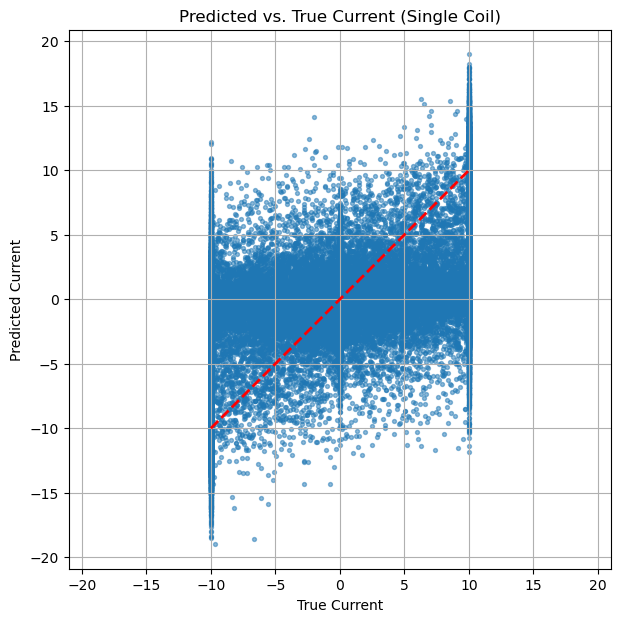

In [110]:
import matplotlib.pyplot as plt

# --- Predict ---
y_pred_n = model.predict([X_va, W_va], batch_size=1024, verbose=0).ravel()
y_pred   = y_pred_n * y_std + y_mean   # de-normalize
y_true   = y_va * y_std + y_mean       # de-normalize

# --- Plot ---
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, s=8, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("True Current")
plt.ylabel("Predicted Current")
plt.title("Predicted vs. True Current (Single Coil)")
plt.grid(True)
plt.axis("equal")
plt.show()


In [111]:
# --- 0) Split into train/val/test FIRST (disjoint) ---
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error

WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
coil_target = "current_16"  # set your coil

feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + [c for c in df.columns if c.startswith("current_")])]
X_all = df[feature_cols].values.astype("float32")
W_all = df[WRENCH_COLS].values.astype("float32")
y_all = df[coil_target].values.astype("float32")

# shuffle once, then split
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_all))
X_all, W_all, y_all = X_all[idx], W_all[idx], y_all[idx]

X_tmp, X_te, W_tmp, W_te, y_tmp, y_te = train_test_split(X_all, W_all, y_all, test_size=0.15, random_state=42)
X_tr,  X_va, W_tr,  W_va, y_tr,  y_va  = train_test_split(X_tmp, W_tmp, y_tmp, test_size=0.1765, random_state=42)  # 0.1765*0.85≈0.15

# --- 1) Fit normalization on TRAIN ONLY ---
eps = 1e-8
X_mean, X_std = X_tr.mean(0), X_tr.std(0) + eps
W_mean, W_std = W_tr.mean(0), W_tr.std(0) + eps
y_mean, y_std = y_tr.mean(), y_tr.std() + eps

def norm_X(x): return (x - X_mean) / X_std
def norm_W(w): return (w - W_mean) / W_std
def norm_y(y): return (y - y_mean) / y_std
def denorm_y(y): return y * y_std + y_mean

X_tr_n, X_va_n, X_te_n = norm_X(X_tr), norm_X(X_va), norm_X(X_te)
W_tr_n, W_va_n, W_te_n = norm_W(W_tr), norm_W(W_va), norm_W(W_te)

# --- 2) Add wrench bias (must be present everywhere) ---
W_tr_n = np.hstack([W_tr_n, np.ones((len(W_tr_n), 1), dtype=np.float32)])
W_va_n = np.hstack([W_va_n, np.ones((len(W_va_n), 1), dtype=np.float32)])
W_te_n = np.hstack([W_te_n, np.ones((len(W_te_n), 1), dtype=np.float32)])

y_tr_n, y_va_n, y_te_n = norm_y(y_tr), norm_y(y_va), norm_y(y_te)

# --- 3) Build & train (your SIREN or linear head); example: linear head for speed ---
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

def build_single_coil_linear_bias(n_features):
    feat_in   = keras.Input(shape=(n_features,), name="features")
    wrench_in = keras.Input(shape=(7,), name="wrench")  # 6 normed + bias
    # simple linear head -> 7 coeffs
    gamma_row = layers.Dense(7, activation="linear", name="gamma_row")(feat_in)
    I_pred = layers.Lambda(lambda t: tf.reduce_sum(t[0]*t[1], axis=-1), name="dot")([gamma_row, wrench_in])
    m = keras.Model([feat_in, wrench_in], I_pred)
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss="mse")
    return m

model = build_single_coil_linear_bias(X_tr_n.shape[1])
model.fit([X_tr_n, W_tr_n], y_tr_n,
          validation_data=([X_va_n, W_va_n], y_va_n),
          epochs=80, batch_size=512, verbose=1)

# --- 4) Evaluate consistently: normalized & raw for both val and test ---
def eval_block(Xn, Wn, y_raw, y_norm, tag):
    y_pred_n = model.predict([Xn, Wn], batch_size=2048, verbose=0).ravel()
    y_pred   = denorm_y(y_pred_n)
    mse_norm = float(mean_squared_error(y_norm, y_pred_n))
    mse_raw  = float(mean_squared_error(y_raw,  y_pred))
    print(f"{tag} MSE (normalized): {mse_norm:.6f} | {tag} MSE (raw A^2): {mse_raw:.6f}")
    return mse_norm, mse_raw

_ = eval_block(X_va_n, W_va_n, y_va, y_va_n, "VAL")
_ = eval_block(X_te_n, W_te_n, y_te, y_te_n, "TEST")


Epoch 1/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 2.8796 - val_loss: 1.0695
Epoch 2/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 918us/step - loss: 1.0257 - val_loss: 1.0070
Epoch 3/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 941us/step - loss: 1.0038 - val_loss: 1.0022
Epoch 4/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 945us/step - loss: 1.0013 - val_loss: 1.0011
Epoch 5/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 951us/step - loss: 1.0007 - val_loss: 1.0006
Epoch 6/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step - loss: 1.0007 - val_loss: 1.0004
Epoch 7/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 960us/step - loss: 1.0006 - val_loss: 1.0015
Epoch 8/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 932us/step - loss: 1.0006 - val_loss: 1.0005
Epoch 9/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 902us/step - loss: 1.0006 - val_loss: 0.9995
Epoch 10/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 913us/step - loss: 1.0005 - val_loss: 1.0006
Epoch 11/80
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2s 922us/step - loss: 1.0006 - val_loss: 0.9997
Epoch 12/8

In [113]:
import matplotlib.pyplot as plt

# Predict
y_pred = model.predict([X_test, W_test], batch_size=512)

# Scatter plot: predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Current")
plt.ylabel("Predicted Current")
plt.title("Predicted vs Actual Current")
plt.grid(True)
plt.show()


NameError: name 'X_test' is not defined

In [115]:
# Optional: quick gradient probe (expect non-zero norms)
with tf.GradientTape() as tape:
    yhat = model([X_tr[:7], W_tr[:7]], training=True)
    loss = tf.reduce_mean((yhat - y_tr[:7])**2)
grads = tape.gradient(loss, model.trainable_weights)
print([float(tf.norm(g)) if g is not None else 0.0 for g in grads[-6:]])


ValueError: Input 1 of layer "functional_2" is incompatible with the layer: expected shape=(None, 7), found shape=(7, 6)

In [116]:
# Step 1 — Label currents into {reverse=-1, off=0, on=+1}
def make_state_labels(y, t_off=1.0, t_on=5.0):
    """
    y: 1D array of currents [A]
    t_off: |y| < t_off -> off
    t_on:  y >= t_on -> on, y <= -t_on -> reverse
    middle band (t_off..t_on) is mapped by sign; tweak if you want to drop it.
    """
    import numpy as np
    y = y.astype(float)
    labels = np.zeros_like(y, dtype=int)
    labels[y >=  t_on]  = +1
    labels[y <= -t_on]  = -1
    mid_pos = (y >=  t_off) & (y <  t_on)
    mid_neg = (y <= -t_off) & (y > -t_on)
    labels[mid_pos] = +1
    labels[mid_neg] = -1
    return labels  # -1, 0, +1


In [117]:
# Step 2 — Train a shallow tree classifier (features + wrench → state)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

coil_target = "current_7"  # pick your coil

WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
current_cols = [c for c in df.columns if c.startswith("current_")]
feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + current_cols)]

X = np.hstack([df[feature_cols].values, df[WRENCH_COLS].values]).astype("float32")
y_reg = df[coil_target].values.astype("float32")
y_cls = make_state_labels(y_reg, t_off=1.0, t_on=5.0)

X_tr, X_te, y_tr, y_te = train_test_split(X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# class weights to handle imbalance
unique, counts = np.unique(y_tr, return_counts=True)
cw = {int(k): float(len(y_tr)/c) for k, c in zip(unique, counts)}

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    n_jobs=-1,
    class_weight=cw,
    random_state=42
)
clf.fit(X_tr, y_tr)

print(classification_report(y_te, clf.predict(X_te), digits=4))
print(confusion_matrix(y_te, clf.predict(X_te)))


              precision    recall  f1-score   support

          -1     0.5594    0.4738    0.5130     96570
           0     0.5754    0.7974    0.6684     64157
           1     0.5578    0.5003    0.5275     96805

    accuracy                         0.5644    257532
   macro avg     0.5642    0.5905    0.5696    257532
weighted avg     0.5628    0.5644    0.5572    257532

[[45754 18786 32030]
 [ 6641 51158  6358]
 [29402 18972 48431]]


kasezldknxgfjlklfdxgcn

In [ ]:
# 1) Labels: {-2, -1, 0, +1, +2}
def make_multistate_labels(y, off=1.0, mid=4.0, high=8.0):
    """
    off: |y| < off -> 0
    mild: off ≤ |y| < mid -> ±1
    strong: mid ≤ |y| < high -> ±2
    clamp any |y| ≥ high to ±2
    """
    import numpy as np
    y = y.astype(float)
    a = np.abs(y)
    lbl = np.zeros_like(y, dtype=int)
    lbl[(a >= off) & (a < mid) & (y > 0)] = +1
    lbl[(a >= off) & (a < mid) & (y < 0)] = -1
    lbl[(a >= mid) & (y > 0)] = +2
    lbl[(a >= mid) & (y < 0)] = -2
    return lbl


In [119]:
# 2) Prepare data + labels (same features as before)
coil_target = "current_7"
WRENCH_COLS = ["wrench_Fx","wrench_Fy","wrench_Fz","wrench_Tx","wrench_Ty","wrench_Tz"]
current_cols = [c for c in df.columns if c.startswith("current_")]
feature_cols = [c for c in df.columns if c not in set(WRENCH_COLS + current_cols)]

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = np.hstack([df[feature_cols].values, df[WRENCH_COLS].values]).astype("float32")
y_reg = df[coil_target].values.astype("float32")
y_cls = make_multistate_labels(y_reg, off=1.0, mid=4.0, high=8.0)

X_tr, X_te, y_tr, y_te = train_test_split(X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# class weights (inverse frequency)
u, c = np.unique(y_tr, return_counts=True)
class_weight = {int(k): float(len(y_tr) / v) for k, v in zip(u, c)}


In [121]:
# 3) Train shallow-ish RF classifier
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=9,
    min_samples_leaf=20,
    n_jobs=-1,
    class_weight=class_weight,
    random_state=42,
    verbose=1

)
clf.fit(X_tr, y_tr)

print(classification_report(y_te, clf.predict(X_te), digits=4))
print(confusion_matrix(y_te, clf.predict(X_te)))


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   54.2s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  1.5min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s


              precision    recall  f1-score   support

          -2     0.6491    0.3601    0.4632     84560
          -1     0.0951    0.2558    0.1387     12010
           0     0.5950    0.7869    0.6776     64157
           1     0.0922    0.2325    0.1320     12096
           2     0.5998    0.4459    0.5115     84709

    accuracy                         0.4838    257532
   macro avg     0.4062    0.4162    0.3846    257532
weighted avg     0.5674    0.4838    0.5018    257532



[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.4s


[[30450 11162 13851 10175 18922]
 [ 1308  3072  3329  2578  1723]
 [ 1926  4975 50485  4251  2520]
 [ 1138  2764  3347  2812  2035]
 [12089 10320 13837 10695 37768]]


[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.7s finished
